In [ ]:
!pip install -q optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 24.6 MB/s eta 0:00:00


In [ ]:
import os, math, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import List, Dict, Tuple, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, accuracy_score

import requests
import re
import time

import os
import pickle
from sklearn.neighbors import NearestNeighbors
from google.colab import files
import shutil
from sklearn.metrics import precision_score, recall_score, matthews_corrcoef, auc
from scipy.stats import pearsonr

from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve
import shap
import requests
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib import cm
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# **1 Data Preprocessing**

In [ ]:
# ---- File paths ----
DATA1 = "Data_1.csv"
DATA2 = "Data_2.csv"

# ---- Reproducibility ----
SEED = 42
rng  = np.random.default_rng(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Train / test split ----
TEST_SIZE = 0.20

# ---- Feature column definitions (manually specified for clarity) ----
# Continuous numeric columns → use z-score standardised later
NUMERIC_COLS = ["size_nm", "zp_mv"]

# Ordinal categorical columns
# → use ordinal encoding later
ORDINAL_COLS = ["incub_time", "washing_steps"]

# Nominal categorical columns
# → one-hot encoding
# 'Not Reported' is treated as a valid category and gets its own dummy column
NOMINAL_COLS = [
    "mod_type", "mod_charge", "np_type", "np_subtype",
    "zp_charge", "zp_solvent", "hd_solvent", "agitation",
]

# Define the ordinal categorical columns orders:
ORDINAL_ORDER: Dict[str, List[str]] = {
    "incub_time"   : ["<30", "30~60", ">60"],
    "washing_steps": ["1~3", "4~6", "Not Reported"],
}

# ---- Protein panel selection ----
MIN_DETECT_THRESHOLD_PCT = 0.0   # %RPA > 0 → protein counted as present
REQUIRE_AT_LEAST_N_NPS   = 10    # protein must appear in at least 10 NPs
COVERAGE_TARGET          = 0.99  # select fewest proteins that cover 99% of total abundance
PLOT_CDF                 = True

# ---- Merge out-of-panel protein abundance into one other bin ----
INCLUDE_OTHER_BIN = True

# ---- Scaling type ----
# "standard" (z-score)
SCALER_KIND = "standard"

# ================================================================
# 1) Utility functions
# ================================================================

# Take the logarithm
def safe_log(x: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    return np.log(np.clip(x, eps, None))

# 80% training set(=train + validation) is used to fit the scaler
def train_val_scalers(
    X_tr: np.ndarray,
    X_val: np.ndarray,
    numeric_idx: List[int],
    kind: str = "standard",
) -> Tuple[np.ndarray, np.ndarray, Optional[object]]:

    if not numeric_idx:
        return X_tr, X_val, None

    Scaler = StandardScaler if kind == "standard" else MinMaxScaler
    scaler = Scaler()
    X_tr2, X_val2 = X_tr.copy(), X_val.copy()
    scaler.fit(X_tr2[:, numeric_idx])
    X_tr2[:, numeric_idx]  = scaler.transform(X_tr2[:, numeric_idx])
    X_val2[:, numeric_idx] = scaler.transform(X_val2[:, numeric_idx])
    return X_tr2, X_val2, scaler

# Shared stratification helper.
def make_quantile_bins(counts: np.ndarray, q: int = 5) -> np.ndarray:
    counts = np.asarray(counts)
    try:
        bins   = pd.qcut(counts, q=q, duplicates="drop", labels=False)
        labels = pd.Series(bins).fillna(0).astype(int).values
        if len(np.unique(labels)) >= 2:
            return labels
    except Exception:
        pass
    return np.zeros(len(counts), dtype=int)

# ================================================================
# 2) Load raw data
# ================================================================

df1 = pd.read_csv(DATA1)
df2 = pd.read_csv(DATA2)

# ---- Data_2: convert %-RPA values to fractions ----
# Define all the protein columns
prot_cols = [c for c in df2.columns if c != "NP_ID"]

# Force each protein column to be converted to numeric, and "Not reported or N/A" will become "NaN"
for c in prot_cols:
    df2[c] = pd.to_numeric(df2[c], errors="coerce")

print(f"[LOAD] Data_1: {df1.shape}  |  Data_2: {df2.shape}")

# ================================================================
# 3) Train / test split  (split on NP_ID to avoid leakage)
# ================================================================
detect_frac    = MIN_DETECT_THRESHOLD_PCT
present_counts = (df2[prot_cols] > detect_frac).sum(axis=1)

# Stratify by number of detected proteins per NP.
# Uses the shared helper so this matches the CV split exactly.
strat_labels_split = make_quantile_bins(present_counts.values)
# If the helper returned all-zeros, there is nothing to stratify on.
strat = strat_labels_split if len(np.unique(strat_labels_split)) >= 2 else None

# Train-test split based on NP_ID
train_ids, test_ids = train_test_split(
    df2["NP_ID"],
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=strat,
)

df2_train = df2[df2["NP_ID"].isin(train_ids)].reset_index(drop=True)
df2_test  = df2[df2["NP_ID"].isin(test_ids)].reset_index(drop=True)

print(f"[SPLIT] Train NPs = {len(df2_train)}   |   Test NPs = {len(df2_test)}")

[LOAD] Data_1: (397, 13)  |  Data_2: (397, 1514)
[SPLIT] Train NPs = 317   |   Test NPs = 80


# **2 Protein Selection**

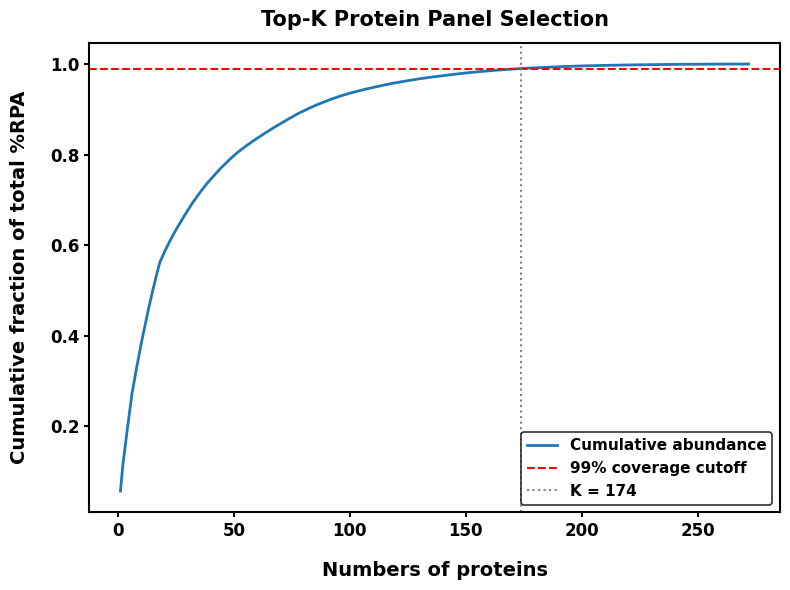

[PANEL] Selected K = 174 proteins (coverage target 99%, min detection = 10 NPs)


In [ ]:
# ================================================================
# 4) Protein panel selection (Top-K by cumulative abundance)
# ================================================================
# Only use the training set to select the panel, test-set protein prevalence does not influence which proteins are modelled.
def select_panel(wide: pd.DataFrame, prot_cols: List[str]) -> List[str]:

    # Compute per-protein total abundance and detection frequency
    sum_abund = wide[prot_cols].sum(axis=0, skipna=True)
    freq_abs  = (wide[prot_cols] > detect_frac).sum(axis=0)
    freq_frac = freq_abs / max(1, len(wide))

    stats = pd.DataFrame({
        "sum_abundance"     : sum_abund,
        "n_nps_detected"    : freq_abs,
        "detection_fraction": freq_frac,
    }).fillna(0.0)

    # Drop proteins detected in too few NPs
    if REQUIRE_AT_LEAST_N_NPS > 0:
        stats = stats[stats["n_nps_detected"] >= REQUIRE_AT_LEAST_N_NPS]

    if stats.empty or stats["sum_abundance"].sum() <= 0:
        raise ValueError("No proteins remain after filtering. "
                         "Try lowering REQUIRE_AT_LEAST_N_NPS.")

    # Rank by total abundance and compute cumulative coverage
    abund_sorted = stats["sum_abundance"].sort_values(ascending=False)
    abund_cdf    = abund_sorted.cumsum() / abund_sorted.sum()

    # Find the minimum K that reaches the coverage target
    idx   = np.where(abund_cdf.values >= COVERAGE_TARGET)[0]
    k     = int(idx[0] + 1) if len(idx) else len(abund_cdf)
    panel = list(abund_cdf.index[:k])

    # Optional CDF plot
    if PLOT_CDF:
        plt.figure(figsize=(8, 6))
        plt.plot(np.arange(1, len(abund_cdf) + 1), abund_cdf.values,
                 label="Cumulative abundance", linewidth=2)
        plt.axhline(COVERAGE_TARGET, linestyle="--", color="red",
                    label=f"{int(COVERAGE_TARGET*100)}% coverage cutoff")
        plt.axvline(k, linestyle=":", color="grey", label=f"K = {k}")

        # Axis labels: bold + bigger + farther from axis
        plt.xlabel("Numbers of proteins",
                   fontsize=14, fontweight='bold', labelpad=15)
        plt.ylabel("Cumulative fraction of total %RPA",
                   fontsize=14, fontweight='bold', labelpad=15)
        plt.title("Top-K Protein Panel Selection",
                  fontsize=15, fontweight='bold', pad=12)

        # Legend
        legend = plt.legend(fontsize=11)
        legend.get_frame().set_edgecolor('black')
        legend.get_frame().set_linewidth(1.2)
        for text in legend.get_texts():
            text.set_fontweight('bold')

        # Axes styling
        ax = plt.gca()
        for spine in ax.spines.values():
            spine.set_edgecolor('black')
            spine.set_linewidth(1.5)
        ax.tick_params(axis='both', width=1.5, colors='black', labelsize=12)
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontweight('bold')

        plt.tight_layout()
        plt.show()

    return panel

panel = select_panel(df2_train, prot_cols)
K     = len(panel)
print(f"[PANEL] Selected K = {K} proteins "
      f"(coverage target {int(COVERAGE_TARGET*100)}%, "
      f"min detection = {REQUIRE_AT_LEAST_N_NPS} NPs)")

# **3 Build feature matrix and align with targets**

In [ ]:
# ================================================================
# 5) Build model targets  (Yp = presence labels, Ya = abundance distribution)
# ================================================================

"""
Construct two target arrays from the wide-format protein table:

Yp : Binary presence labels: 1 if %RPA > threshold, else 0.
Ya : Relative abundance distribution (sums to 1 per row).
     If INCLUDE_OTHER_BIN=True, the last column ('OTHER') captures
     the combined abundance of all proteins outside the panel.
"""

def build_targets(
    wide: pd.DataFrame,
    panel: List[str],
) -> Tuple[np.ndarray, np.ndarray, List[str]]:

    # Construct the present matrixs
    present = (wide[panel] > detect_frac).astype(float)

    # Build the original value of abundance panel
    # If a negative number or NaN appears, fill in it with 0
    abund   = wide[panel].clip(lower=0.0).fillna(0.0)
    # Sum abundance of ALL proteins, then subtract presence panel to get leftover
    if INCLUDE_OTHER_BIN:
        # Find all the protein columns, except NP_ID column
        all_prot_cols = [c for c in wide.columns if c != "NP_ID"]
        # For each sample, calculate the total abundance of all proteins.
        total_all   = wide[all_prot_cols].clip(lower=0.0).fillna(0.0).sum(axis=1)
        # The total abundance of each sample on these proteins in the panel
        total_panel = abund.sum(axis=1)
        # Calculate the residual abundance outside the panel
        leftover    = (total_all - total_panel).clip(lower=0.0)

        out_cols = panel + ["OTHER"]
        Yp = np.zeros((len(wide), len(out_cols)), dtype=np.float32)
        Ya = np.zeros_like(Yp)

        Yp[:, :len(panel)] = present.values
        Yp[:, -1]          = (leftover.values > detect_frac).astype(np.float32)

        abund_plus = pd.concat([abund, leftover.rename("OTHER")], axis=1)
        denom = abund_plus.sum(axis=1).replace(0.0, np.nan)
        frac  = abund_plus.div(denom, axis=0).fillna(0.0)
        Ya[:, :] = frac.values.astype(np.float32)

    else:
        out_cols = panel
        Yp = present.values.astype(np.float32)
        denom = abund.sum(axis=1).replace(0.0, np.nan)
        frac  = abund.div(denom, axis=0).fillna(0.0)
        Ya    = frac.values.astype(np.float32)

    return Yp, Ya, out_cols


Yp_tr, Ya_tr, OUT_COLS   = build_targets(df2_train, panel)
Yp_te, Ya_te, OUT_COLS_2 = build_targets(df2_test,  panel)
assert OUT_COLS == OUT_COLS_2, "Train/test output column mismatch."
print(f"Presence {Yp_tr.shape}  |  Abundance {Ya_tr.shape}")


# ================================================================
# 6) Feature engineering  (Data_1 → model input X)
# ================================================================

def encode_ordinal(series: pd.Series, ordered_cats: List[str]) -> pd.Series:
    mapping = {cat: i for i, cat in enumerate(ordered_cats)}
    codes   = series.map(mapping).fillna(-1).astype(int)
    codes   = codes.clip(lower=0)   # treat unknowns as lowest level
    return codes

# Convert the raw NP property table (Data_1) into a numeric design matrix.
def build_feature_matrix(df1_props: pd.DataFrame) -> Tuple[pd.DataFrame, List[str], List[int]]:
    df = df1_props.copy()

    # ---- Numeric block ----
    # Convert to float first.
    for c in NUMERIC_COLS:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    num_medians = df[NUMERIC_COLS].median()
    df[NUMERIC_COLS] = df[NUMERIC_COLS].fillna(num_medians)
    X_num = df[NUMERIC_COLS].astype(np.float32)

    # ---- Ordinal block ----
    X_ord = pd.DataFrame(index=df.index)
    for c in ORDINAL_COLS:
        order       = ORDINAL_ORDER[c]
        X_ord[c]    = encode_ordinal(df[c], order).astype(np.float32)

    # ---- Nominal block (one-hot) ----
    # 'Not Reported' is a meaningful category,
    # so we keep it as a regular value rather than dropping it.
    X_nom = pd.get_dummies(
        df[NOMINAL_COLS].astype(str),
        dummy_na=False,
    ).astype(np.float32)

    # ---- Concatenate all blocks ----
    X_all    = pd.concat([df[["NP_ID"]], X_num, X_ord, X_nom], axis=1)
    feat_cols = [c for c in X_all.columns if c != "NP_ID"]

    # Record which positions in feat_cols correspond to the numeric columns
    # (only these will be passed to the StandardScaler later)
    numeric_idx = [i for i, c in enumerate(feat_cols) if c in NUMERIC_COLS]

    return X_all, feat_cols, numeric_idx


# Build the full feature matrix from Data_1
Xdf_all, FEAT_COLS, NUM_IDX = build_feature_matrix(df1)

# Align feature rows to the train/test NP_ID order defined by Data_2
# (left-join keeps Data_2 row order; all NP_IDs are guaranteed to match)
Xdf_tr = df2_train[["NP_ID"]].merge(Xdf_all, on="NP_ID", how="left")
Xdf_te = df2_test [["NP_ID"]].merge(Xdf_all, on="NP_ID", how="left")

X_raw_tr = Xdf_tr[FEAT_COLS].values.astype(np.float32)
X_raw_te = Xdf_te[FEAT_COLS].values.astype(np.float32)

print(f"Train: {X_raw_tr.shape}     |     Test: {X_raw_te.shape}")
print(f"Numeric columns to scale: {[FEAT_COLS[i] for i in NUM_IDX]}")
print(f"Total feature dimensions: {len(FEAT_COLS)}")

Presence (317, 175)  |  Abundance (317, 175)
Train: (317, 55)     |     Test: (80, 55)
Numeric columns to scale: ['size_nm', 'zp_mv']
Total feature dimensions: 55


In [ ]:
Yp_tr_df = pd.DataFrame(Yp_tr, columns=OUT_COLS)
Ya_tr_df = pd.DataFrame(Ya_tr, columns=OUT_COLS)
Yp_tr_df.insert(0, "NP_ID", df2_train["NP_ID"].values)
Ya_tr_df.insert(0, "NP_ID", df2_train["NP_ID"].values)

# **4 Protein Functional Category**

In [ ]:
# ----------------------------------------------------------------
# 1) Fetch protein names from UniProt REST API
# ----------------------------------------------------------------
UNIPROT_URL    = "https://rest.uniprot.org/uniprotkb/search"
BATCH_SIZE     = 25                  # UniProt API limit
RETRY_PER_BATCH = 3
TIMEOUT_SEC    = 30


def fetch_uniprot_names(accession_ids: List[str]) -> Dict[str, str]:

    name_map: Dict[str, str] = {}

    for i in range(0, len(accession_ids), BATCH_SIZE):
        batch = accession_ids[i : i + BATCH_SIZE]
        # Build the OR-joined accession query
        query = " OR ".join([f"accession:{a}" for a in batch])
        params = {
            "query"  : query,
            "format" : "json",
            "fields" : "accession,protein_name",
            "size"   : BATCH_SIZE,
        }

        for attempt in range(1, RETRY_PER_BATCH + 1):
            try:
                resp = requests.get(UNIPROT_URL, params=params, timeout=TIMEOUT_SEC)
                resp.raise_for_status()
                data = resp.json()
                break
            except Exception as e:
                if attempt == RETRY_PER_BATCH:
                    print(f"  [WARN] Batch {i//BATCH_SIZE + 1} failed after "
                          f"{RETRY_PER_BATCH} attempts: {e}")
                    data = {"results": []}
                else:
                    time.sleep(1.5 * attempt)

        # Extract name per result
        for entry in data.get("results", []):
            acc = entry.get("primaryAccession", "")
            pn  = entry.get("proteinDescription", {}) or {}

            name = ""
            rec  = pn.get("recommendedName", {}) or {}
            if rec:
                name = (rec.get("fullName", {}) or {}).get("value", "")
            if not name:
                subs = pn.get("submissionNames", []) or []
                if subs:
                    name = (subs[0].get("fullName", {}) or {}).get("value", "")
            name_map[acc] = name or "<UNKNOWN>"

        time.sleep(0.2)

    # Fill in any IDs that didn't come back in the response
    for a in accession_ids:
        if a not in name_map:
            name_map[a] = "<UNKNOWN>"

    return name_map


# ----------------------------------------------------------------
# 2) Run the query
# ----------------------------------------------------------------

panel_proteins = [c for c in OUT_COLS if c != "OTHER"]

print(f"[INFO] Querying UniProt for {len(panel_proteins)} accessions "
      f"(in batches of {BATCH_SIZE})...")
id_to_name = fetch_uniprot_names(panel_proteins)
n_unknown = sum(1 for v in id_to_name.values() if v == "<UNKNOWN>")
print(f"[INFO] Done. {len(id_to_name) - n_unknown} resolved, "
      f"{n_unknown} unresolved.")


# ----------------------------------------------------------------
# 3) Rule-based category assignment from protein names (REVISED)
# ----------------------------------------------------------------

def categorize_name(name: str) -> str:
    """
    Map a protein name to one of the 9 categories from Project 1.
    Returns 'Other/Mixed' if no rule matches or the name is unknown.
    """
    if not name or name == "<UNKNOWN>":
        return "Other/Mixed"

    n = name.lower()

    # --- Apolipoproteins ---
    if "apolipoprotein" in n or n.startswith("apo "):
        return "Apolipoproteins"

    # --- Coagulation / Fibrinogen ---
    if ("fibrinogen" in n
        or "coagulation factor" in n
        or "prothrombin" in n
        or "tissue factor" in n
        or "vitamin k-dependent" in n
        or "heparin cofactor" in n
        or "antiplasmin" in n
        or "antithrombin" in n
        or "platelet factor" in n
        or "platelet basic protein" in n
        or "platelet glycoprotein" in n):
        return "Coagulation/Fibrinogen"

    # --- Complement System ---
    if ("complement" in n
        or "properdin" in n
        or "ficolin" in n
        or re.search(r"\bc[1-9][a-z0-9\-]*\b", n)):
        if "c-reactive" not in n:
            return "Complement System"

    # --- Cytoskeletal & cytoskeleton-associated ---
    if any(k in n for k in [
        "keratin", "actin", "tubulin", "myosin", "filamin",
        "tropomyosin", "vimentin", "spectrin", "alpha-actinin",
        "profilin", "gelsolin", "talin", "annexin", "cofilin",
        "vinculin", "moesin", "ezrin", "integrin",
        "band 3 anion",
    ]):
        return "Cytoskeletal"

    # --- Immunoglobulins ---
    if "immunoglobulin" in n:
        return "Immunoglobulins"

    # --- Metabolic Enzymes ---
    if any(k in n for k in [
        "kinase", "dehydrogenase", "isomerase", "oxidase",
        "peroxidase", "transferase", "reductase", "synthase",
        "phosphatase", "hydrolase", "esterase",
        "enolase", "lysozyme",
    ]):
        return "Metabolic Enzymes"

    # --- Protease / Inhibitors ---
    if any(k in n for k in [
        "protease", "proteinase", "inhibitor",
        "antitrypsin", "antichymotrypsin", "serpin",
        "kininogen", "plasminogen", "kallikrein",
        "carboxypeptidase",
    ]):
        return "Protease/Inhibitors"

    # --- Transport / Binding ---
    if any(k in n for k in [
        "albumin", "transferrin", "haptoglobin", "hemopexin",
        "ceruloplasmin", "transthyretin", "vitamin d-binding",
        "retinol-binding", "binding protein", "binding-protein",
        "galectin", "lipopolysaccharide-binding",
        "insulin-like growth factor-binding",
        "alpha-2-macroglobulin", "alpha-1-acid glycoprotein",
        "vitronectin", "clusterin", "fibronectin",
        "thrombospondin", "histidine-rich glycoprotein",
        "beta-2-glycoprotein", "alpha-2-hs-glycoprotein",
        "alpha-1b-glycoprotein", "ambp",
        "selenoprotein p",
        "pigment epithelium-derived factor",
        "cartilage oligomeric matrix",
    ]):
        return "Transport/Binding"

    return "Other/Mixed"

id_to_cat = {acc: categorize_name(nm) for acc, nm in id_to_name.items()}

# ----------------------------------------------------------------
# 4) Audit report
# ----------------------------------------------------------------

CATEGORY_ORDER = [
    "Apolipoproteins",
    "Coagulation/Fibrinogen",
    "Complement System",
    "Cytoskeletal",
    "Immunoglobulins",
    "Metabolic Enzymes",
    "Protease/Inhibitors",
    "Transport/Binding",
    "Other/Mixed",
]

cat_series = pd.Series(
    [id_to_cat[a] for a in panel_proteins],
    index=panel_proteins,
    name="category",
)
cat_counts = cat_series.value_counts().reindex(CATEGORY_ORDER, fill_value=0)
cat_pct    = (cat_counts / len(panel_proteins) * 100).round(2)

audit_df = pd.DataFrame({
    "n_proteins" : cat_counts.values,
    "percentage" : cat_pct.values,
}, index=CATEGORY_ORDER)


# ----------------------------------------------------------------
# 5) Print report
# ----------------------------------------------------------------

print("\n" + "=" * 72)
print(f"  CATEGORY COVERAGE AUDIT (panel size = {len(panel_proteins)})")
print("=" * 72)
print(audit_df.to_string())

n_other     = int(cat_counts["Other/Mixed"])
pct_other   = n_other / len(panel_proteins) * 100
pct_covered = 100.0 - pct_other

print("=" * 72)

[INFO] Querying UniProt for 174 accessions (in batches of 25)...
[INFO] Done. 174 resolved, 0 unresolved.

  CATEGORY COVERAGE AUDIT (panel size = 174)
                        n_proteins  percentage
Apolipoproteins                 15        8.62
Coagulation/Fibrinogen          19       10.92
Complement System               25       14.37
Cytoskeletal                    22       12.64
Immunoglobulins                 24       13.79
Metabolic Enzymes                6        3.45
Protease/Inhibitors             15        8.62
Transport/Binding               28       16.09
Other/Mixed                     20       11.49


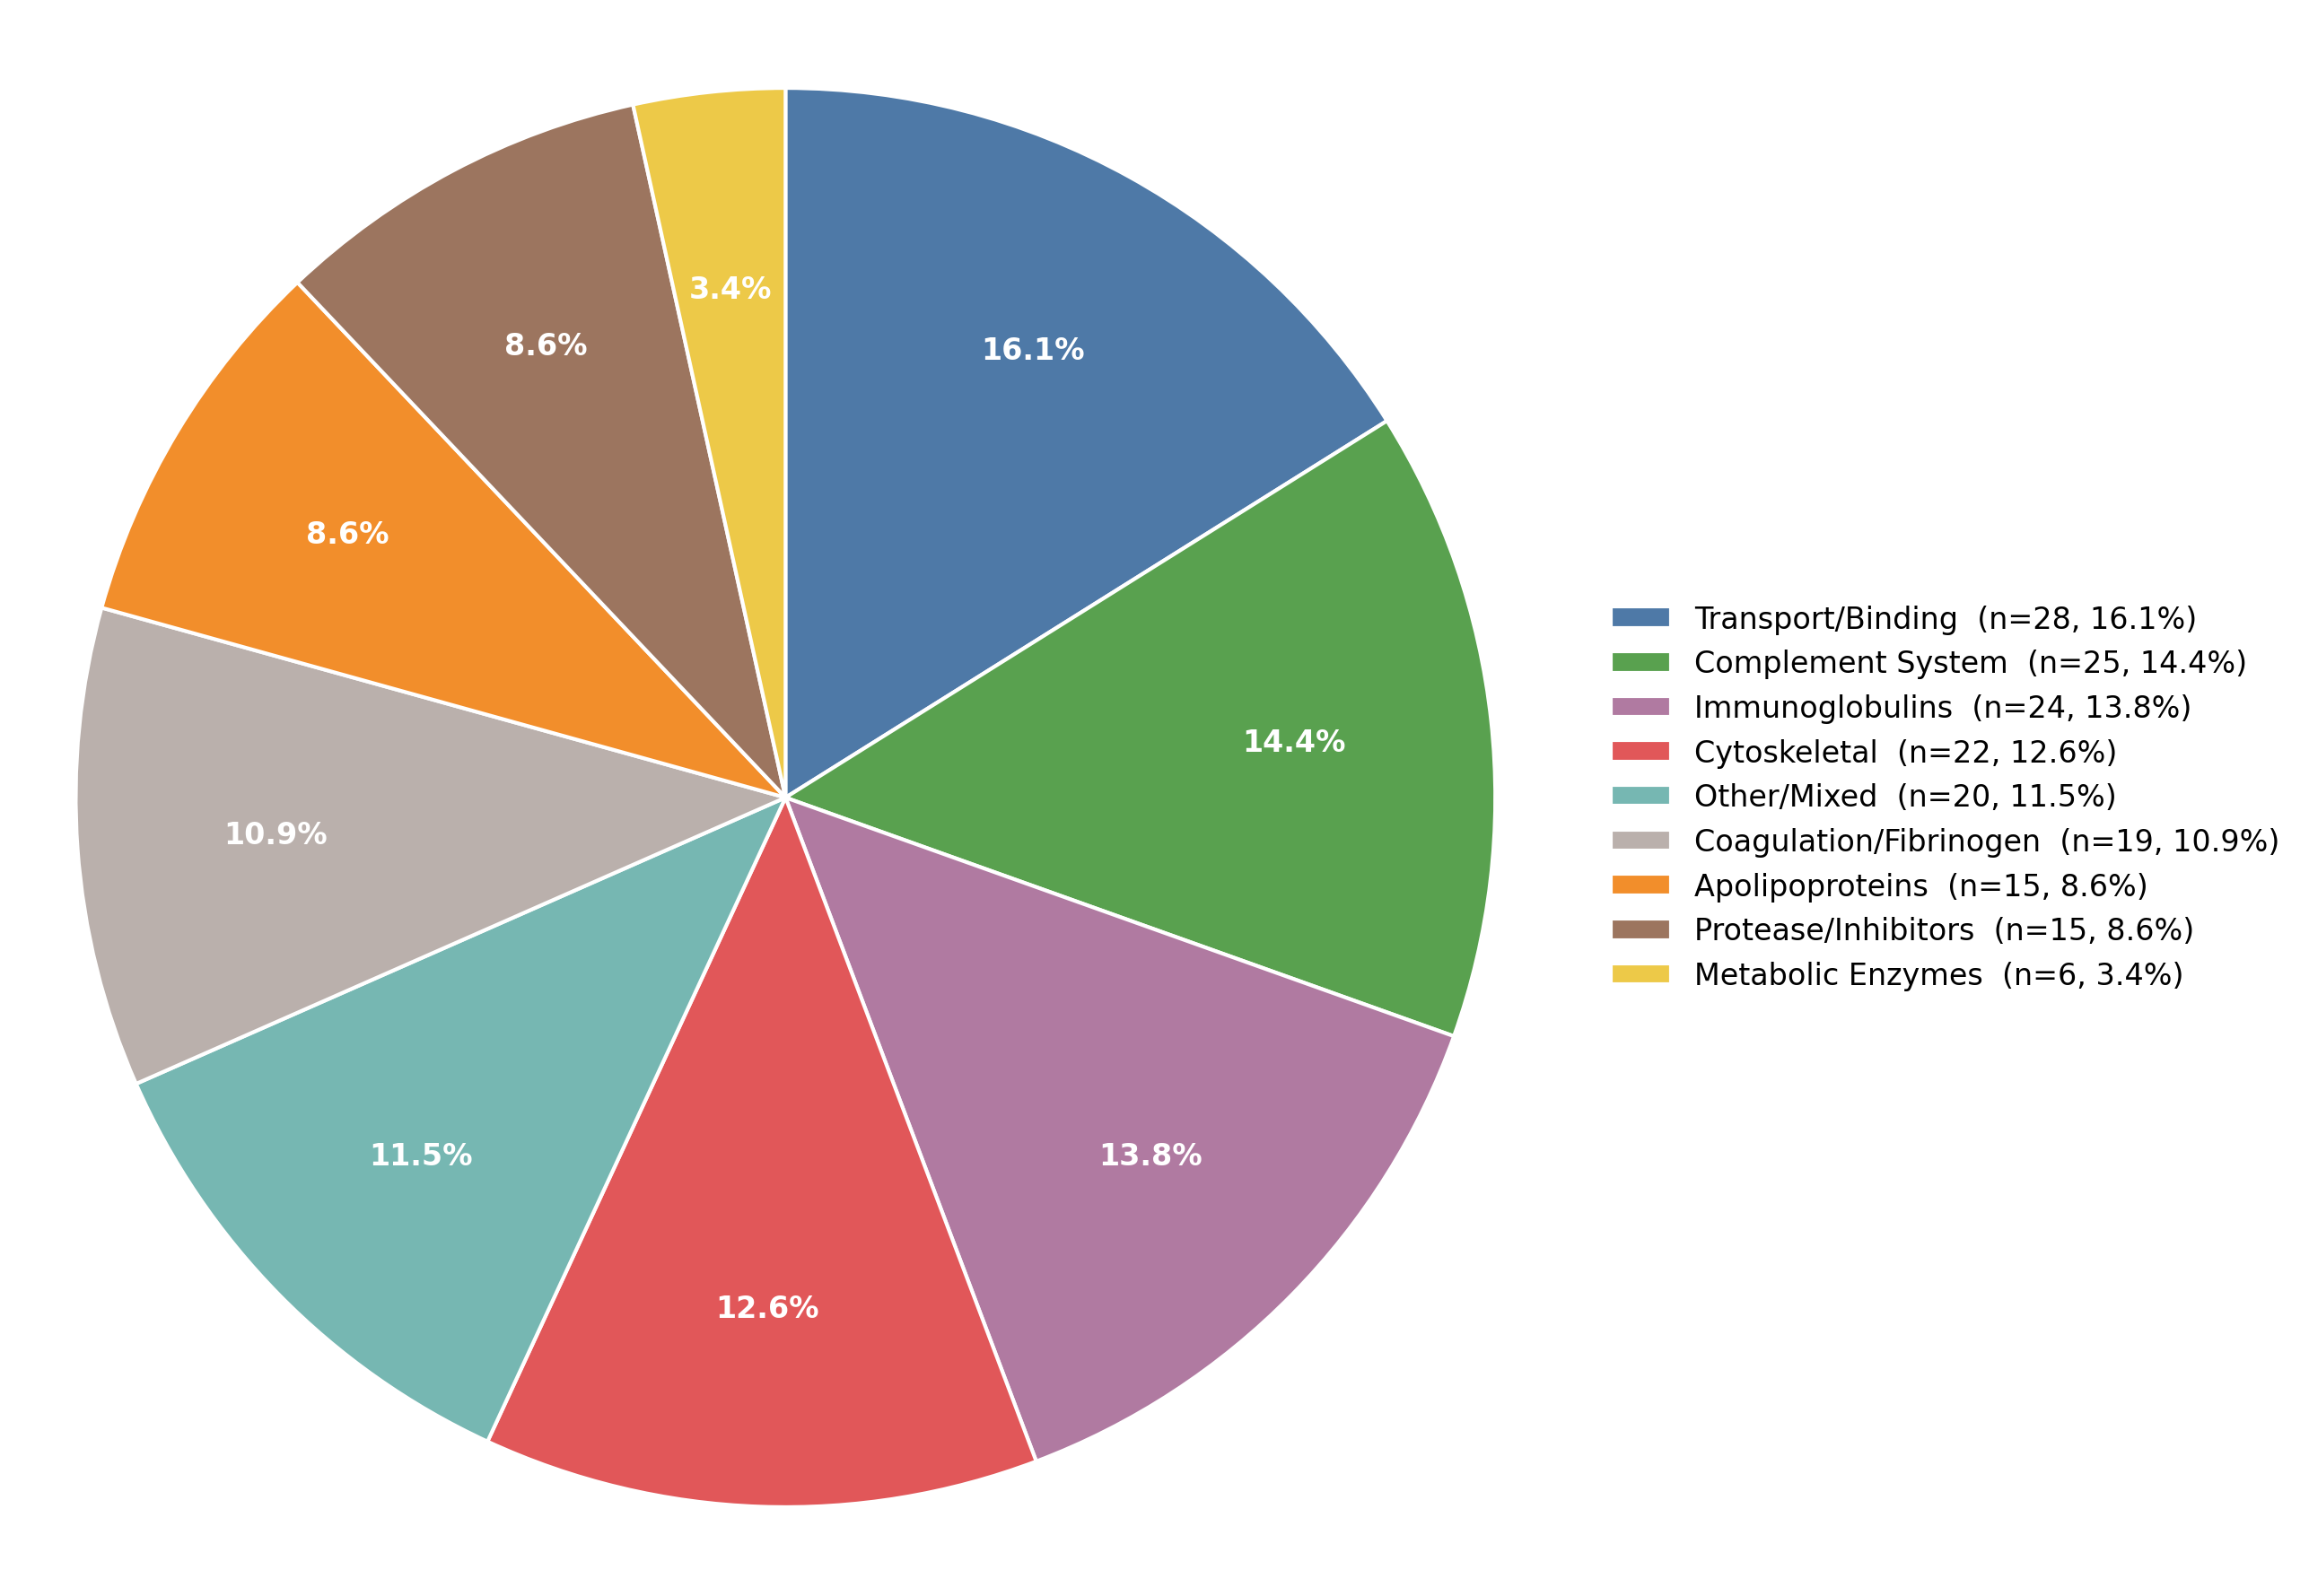

In [ ]:
# ================================================================
# PIE CHART — Protein Category Distribution
# ================================================================

# ---- Filter out empty categories ----
plot_df = audit_df.copy()
plot_df = plot_df[plot_df["n_proteins"] > 0]

# ---- Sort by size descending (better visual layout) ----
plot_df = plot_df.sort_values("n_proteins", ascending=False)

labels = plot_df.index.tolist()
sizes  = plot_df["n_proteins"].values
total  = sizes.sum()
pcts   = sizes / total * 100

# ---- Colour palette (Tableau-10 style) ----
colors = [
    "#4E79A7",  # blue
    "#59A14F",  # green
    "#B07AA1",  # purple
    "#E15759",  # red
    "#76B7B2",  # teal
    "#BAB0AC",  # grey
    "#F28E2B",  # orange
    "#9C755F",  # brown
    "#EDC948",  # yellow
]


# ---- Hide inline % label when slice is too small to read ----
SMALL_SLICE_PCT = 3.0
def _autopct(pct):
    return f"{pct:.1f}%" if pct >= SMALL_SLICE_PCT else ""

fig, ax = plt.subplots(figsize=(13, 9), dpi=200)

wedges, texts, autotexts = ax.pie(
    sizes,
    labels        = None,
    colors        = colors[:len(sizes)],
    autopct       = _autopct,
    startangle    = 90,
    counterclock  = False,
    pctdistance   = 0.72,
    wedgeprops    = {"edgecolor": "white", "linewidth": 1.5},
    textprops     = {"fontsize": 11, "color": "black"},
)

# ---- Bold percentage labels on wedges ----
for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_fontweight("bold")
    autotext.set_color("white")

# ---- Legend ----
legend_labels = [
    f"{lab}  (n={n}, {p:.1f}%)"
    for lab, n, p in zip(labels, sizes, pcts)
]
ax.legend(
    wedges,
    legend_labels,
    loc            = "center left",
    bbox_to_anchor = (1.02, 0.5),
    fontsize       = 12,
    frameon        = False,
)

ax.axis("equal")

plt.tight_layout()
plt.savefig("figure_protein_category_pie.png",
            dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
# ================================================================
# SUPPLEMENTARY — Per-category protein listing
# ================================================================

# ---- Build one long (tidy) table: one row per protein ----
si_rows = []
for acc in panel_proteins:
    si_rows.append({
        "Category"  : id_to_cat[acc],
        "Accession" : acc,
        "Protein_name": id_to_name.get(acc, "<UNKNOWN>"),
    })

si_df = pd.DataFrame(si_rows)

# ---- Sort: category first (fixed order), then name alphabetically ----
# Categorical dtype forces the rows to follow CATEGORY_ORDER, not A-Z.
si_df["Category"] = pd.Categorical(
    si_df["Category"], categories=CATEGORY_ORDER, ordered=True
)
si_df = si_df.sort_values(
    ["Category", "Protein_name"]
).reset_index(drop=True)

# ---- Add a per-category index (1,2,3... restarting each category) ----
# cumcount() counts rows within each group, starting at 0 -> +1 for 1-based.
si_df["No."] = si_df.groupby("Category", observed=True).cumcount() + 1

# Reorder columns for the final table
si_df = si_df[["Category", "No.", "Accession", "Protein_name"]]


# ================================================================
# 1) Print a readable, grouped report (for quick checking)
# ================================================================
print("=" * 72)
print(f"  PER-CATEGORY PROTEIN LISTING (total = {len(si_df)})")
print("=" * 72)

for cat in CATEGORY_ORDER:
    sub = si_df[si_df["Category"] == cat]
    if sub.empty:                      # skip categories with no proteins
        continue
    print(f"\n{cat}  (n = {len(sub)})")
    print("-" * 72)
    for _, r in sub.iterrows():
        print(f"  {r['No.']:3d}.  {r['Accession']:10s}  {r['Protein_name']}")

print("\n" + "=" * 72)


# ================================================================
# 2) Save to CSV (for pasting into the SI table)
# ================================================================
si_df.to_csv("SI_protein_category_listing.csv", index=False)
print("[INFO] Saved -> SI_protein_category_listing.csv")

  PER-CATEGORY PROTEIN LISTING (total = 174)

Apolipoproteins  (n = 15)
------------------------------------------------------------------------
    1.  P02647      Apolipoprotein A-I
    2.  P02652      Apolipoprotein A-II
    3.  P06727      Apolipoprotein A-IV
    4.  Q6Q788      Apolipoprotein A-V
    5.  P04114      Apolipoprotein B-100
    6.  P02654      Apolipoprotein C-I
    7.  P02655      Apolipoprotein C-II
    8.  P02656      Apolipoprotein C-III
    9.  P55056      Apolipoprotein C-IV
   10.  P05090      Apolipoprotein D
   11.  P02649      Apolipoprotein E
   12.  Q13790      Apolipoprotein F
   13.  O14791      Apolipoprotein L1
   14.  O95445      Apolipoprotein M
   15.  P08519      Apolipoprotein(a)

Coagulation/Fibrinogen  (n = 19)
------------------------------------------------------------------------
    1.  P08697      Alpha-2-antiplasmin
    2.  P01008      Antithrombin-III
    3.  P00740      Coagulation factor IX
    4.  P12259      Coagulation factor V
    5

# **5 Model**

##5.1 Training config

In [ ]:
# ================================================================
# 1) Training Config
# ================================================================

# ---- Training ----
MAX_EPOCHS          = 100
EARLY_STOP_PATIENCE = 10
BATCH_SIZE          = 64
N_FOLDS             = 5

# ---- Loss weights ----
WEIGHT_PRESENCE = 1.0

# The values below are ONLY defaults for GRID_FALLBACK (used when Optuna is not available).
WEIGHT_ABUND    = 1.5

# ---- Gating & temperature ----
# These will be searched by Optuna; this is a fallback-only default.
GATE_ALPHA    = 2.0
TEMP_INIT     = 1.0     # This only sets where it starts.
STOPGRAD_GATE = True

# ---- Composite score weights ----
# Equal weighting of presence (AUROC) and abundance (1 - L1/2) head
W_AUROC      = 0.5
W_L1_INVERSE = 0.5

# ---- Dev set ----
DEV_RATIO   = 0.15


# ================================================================
# 2) Utility functions
# ================================================================

def compute_pos_weight(Yp: np.ndarray, device: torch.device) -> torch.Tensor:
    n_pos = Yp.sum(axis=0).clip(min=1)
    n_neg = (1 - Yp).sum(axis=0).clip(min=1)
    pw    = (n_neg / n_pos).clip(min=1.0)
    return torch.tensor(pw, dtype=torch.float32, device=device)

## 5.2 Model structure and metrics

In [ ]:
# ================================================================
# 3) Model architecture
# ================================================================

class MLP(nn.Module):
    def __init__(self, in_dim: int, widths: List[int], dropout: float = 0.0):
        super().__init__()
        layers, d = [], in_dim
        for w in widths:
            layers += [nn.Linear(d, w), nn.ReLU()]
            if dropout > 0:
                layers += [nn.Dropout(dropout)]
            d = w
        self.net     = nn.Sequential(*layers)
        self.out_dim = d

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class TwoHead(nn.Module):
    def __init__(
        self,
        in_dim: int,
        hidden: List[int],
        k: int,
        dropout: float,
        alpha_gate: float = GATE_ALPHA,
        temp_init: float  = TEMP_INIT,
    ):
        super().__init__()
        self.enc   = MLP(in_dim, hidden, dropout)
        H          = self.enc.out_dim
        self.pres  = nn.Linear(H, k)   # presence head: outputs K logits
        self.abun  = nn.Linear(H, k)   # abundance head: outputs K logits
        self.alpha = nn.Parameter(torch.tensor(float(alpha_gate)))
        self.temp  = nn.Parameter(torch.tensor(float(temp_init)))

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        z            = self.enc(x)
        pres_logits  = self.pres(z)    # (B, K)
        abund_logits = self.abun(z)    # (B, K)

        # Gate: use the presence prediction to "open" or "close" each
        # protein in the abundance output. If a protein is unlikely to
        # be present, its abundance is pushed down.
        if STOPGRAD_GATE:
            gate = torch.sigmoid(self.alpha * pres_logits.detach())
        else:
            gate = torch.sigmoid(self.alpha * pres_logits)

        # Add log(gate) to the logits, then softmax. Adding log(gate)
        # before softmax is the same as multiplying probabilities by
        # the gate, but it is numerically safer.
        masked        = abund_logits + torch.log(gate + 1e-8)

        # Temperature controls how sharp the predicted distribution is.
        # T < 1 makes it sharper (a few proteins dominate).
        # T > 1 makes it flatter. T is learned during training.
        T             = self.temp.clamp(0.5, 5.0)
        abund_logprob = F.log_softmax(masked / T, dim=1)

        return pres_logits, abund_logprob

# ================================================================
# 4) Metrics
# ================================================================

@torch.no_grad()
def predict_probs(
    model: TwoHead,
    xb_t: torch.Tensor,
) -> Tuple[np.ndarray, np.ndarray]:
    model.eval()
    pres_logits, abund_logprob = model(xb_t)
    return (torch.sigmoid(pres_logits).cpu().numpy(),
            torch.exp(abund_logprob).cpu().numpy())


def presence_metrics(
    y_true_bin: np.ndarray,
    y_prob: np.ndarray,
) -> Dict[str, float]:
    aurocs, auprcs = [], []
    for j in range(y_true_bin.shape[1]):
        yt, yp = y_true_bin[:, j], y_prob[:, j]
        if len(np.unique(yt)) < 2:
            continue
        try:
            aurocs.append(roc_auc_score(yt, yp))
            auprcs.append(average_precision_score(yt, yp))
        except ValueError:
            pass

    macro_auroc = float(np.mean(aurocs)) if aurocs else np.nan
    macro_auprc = float(np.mean(auprcs)) if auprcs else np.nan
    y_hat       = (y_prob >= 0.5).astype(int)
    macro_f1    = f1_score(y_true_bin, y_hat, average="macro",  zero_division=0)
    micro_f1    = f1_score(y_true_bin, y_hat, average="micro",  zero_division=0)
    acc         = accuracy_score(y_true_bin.flatten(), y_hat.flatten())

    return {
        "macro_auroc"  : macro_auroc,
        "macro_auprc"  : macro_auprc,
        "macro_f1@0.5" : float(macro_f1),
        "micro_f1@0.5" : float(micro_f1),
        "acc@0.5"      : float(acc),
    }


def abundance_metrics(
    y_true_dist: np.ndarray,
    y_pred_dist: np.ndarray,
) -> Dict[str, float]:
    eps    = 1e-12
    y_true = np.clip(y_true_dist.copy(), eps, None)
    y_pred = np.clip(y_pred_dist.copy(), eps, None)
    y_true /= y_true.sum(axis=1, keepdims=True)
    y_pred /= y_pred.sum(axis=1, keepdims=True)

    num      = (y_true * y_pred).sum(axis=1)
    den      = np.clip(
        np.linalg.norm(y_true, axis=1) * np.linalg.norm(y_pred, axis=1),
        eps, None
    )
    mean_cos = float(np.mean(num / den))

    mean_l1  = float(np.mean(np.abs(y_true - y_pred).sum(axis=1)))

    return {
        "mean_cosine"        : mean_cos,
        "mean_L1"            : mean_l1,
    }


def composite_score(pm: Dict[str, float], am: Dict[str, float]) -> float:
    auroc = 0.0 if np.isnan(pm.get("macro_auroc", np.nan)) else pm["macro_auroc"]
    l1    = 2.0 if np.isnan(am.get("mean_L1",     np.nan)) else am["mean_L1"]
    l1_sim = max(0.0, 1.0 - l1 / 2.0)

    return W_AUROC * auroc + W_L1_INVERSE * l1_sim

# ================================================================
# 5) Trainer
# ================================================================

class Trainer:
    def __init__(self, in_dim: int, k: int, cfg: Dict, pos_weight: torch.Tensor):
        self.model = TwoHead(
            in_dim,
            cfg["HIDDEN"],
            k,
            cfg["DROPOUT"],
            alpha_gate=cfg["ALPHA"],
            temp_init=cfg["TEMP_INIT"],
        ).to(device)
        self.opt = torch.optim.Adam(
            self.model.parameters(),
            lr=cfg["LR"],
            weight_decay=cfg["WD"],
        )

        # Presence loss: class-weighted binary cross-entropy on logits.
        self.bce = nn.BCEWithLogitsLoss(
            pos_weight=pos_weight,
            reduction="mean",
        )
        # Abundance loss: KL divergence between predicted and true
        self.kld = nn.KLDivLoss(reduction="batchmean")

        self.w_pres  = cfg["W_PRES"]
        self.w_abund = cfg["W_ABUND"]

    def step(
        self,
        xb: torch.Tensor,
        ypb: torch.Tensor,
        yab: torch.Tensor,
        train: bool = True,
    ) -> Tuple[float, float, float]:

        if train:
            self.model.train()
            self.opt.zero_grad()
        else:
            self.model.eval()

        pres_logits, abund_logprob = self.model(xb)

        # Presence loss: how well we predict which proteins are present.
        lp = self.bce(pres_logits, ypb)

        # Abundance loss: how close the predicted distribution is to
        # the true relative-abundance distribution.
        la = self.kld(abund_logprob, yab)

        # Total loss = weighted sum of the two heads.
        loss = (self.w_pres  * lp
              + self.w_abund * la)

        if train:
            loss.backward()
            self.opt.step()

        return (loss.item(), lp.item(), la.item())

## 5.3 Training

In [ ]:
# ================================================================
# 6) Cross-validation (StratifiedKFold) no need to run when load model
# ================================================================

def fold_train_eval(
    X: np.ndarray,
    Yp: np.ndarray,
    Ya: np.ndarray,
    tr_idx: np.ndarray,
    va_idx: np.ndarray,
    cfg: Dict,
) -> Tuple[float, Dict, Dict]:

    X_tr_raw, X_va_raw = X[tr_idx], X[va_idx]
    Yp_tr, Yp_va       = Yp[tr_idx], Yp[va_idx]
    Ya_tr, Ya_va       = Ya[tr_idx], Ya[va_idx]

    # Scale numeric features (fit on train fold only)
    X_tr, X_va, _ = train_val_scalers(X_tr_raw, X_va_raw, NUM_IDX, SCALER_KIND)

    # Compute class weights from the training fold labels
    pw = compute_pos_weight(Yp_tr, device)

    # Build data loader for the training fold
    to_t   = lambda a: torch.tensor(a, dtype=torch.float32)
    dl_tr  = DataLoader(
        TensorDataset(to_t(X_tr), to_t(Yp_tr), to_t(Ya_tr)),
        batch_size=BATCH_SIZE,
        shuffle=True,
    )

    T = Trainer(in_dim=X.shape[1], k=Yp.shape[1], cfg=cfg, pos_weight=pw)

    best_score, best_state, no_improve = -np.inf, None, 0

    for ep in range(1, MAX_EPOCHS + 1):
        # ---- Training pass ----
        for xb, ypb, yab in dl_tr:
            xb, ypb, yab = xb.to(device), ypb.to(device), yab.to(device)
            T.step(xb, ypb, yab, train=True)

        # ---- Validation pass ----
        with torch.no_grad():
            xb_va  = torch.tensor(X_va, dtype=torch.float32, device=device)
            y_prob, y_dist = predict_probs(T.model, xb_va)

        pm   = presence_metrics(Yp_va, y_prob)
        am   = abundance_metrics(Ya_va, y_dist)
        comp = composite_score(pm, am)

        # ---- Early stopping (patience = EARLY_STOP_PATIENCE) ----
        if comp > best_score + 1e-6:
            best_score = comp
            no_improve = 0
            best_state = {k: v.detach().cpu().clone()
                          for k, v in T.model.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= EARLY_STOP_PATIENCE:
                break

    # Restore best checkpoint and re-evaluate
    T.model.load_state_dict(best_state)
    with torch.no_grad():
        xb_va  = torch.tensor(X_va, dtype=torch.float32, device=device)
        y_prob, y_dist = predict_probs(T.model, xb_va)

    pm   = presence_metrics(Yp_va, y_prob)
    am   = abundance_metrics(Ya_va, y_dist)
    comp = composite_score(pm, am)
    return comp, pm, am

# Run N_FOLDS-fold StratifiedKFold cross-validation on the training set.
def cv_score(
    X: np.ndarray,
    Yp: np.ndarray,
    Ya: np.ndarray,
    cfg: Dict,
) -> Tuple[float, List[Dict], List[Dict]]:

    # Use the SAME shared stratification helper as the train/test split.
    # We bin each sample by its total number of detected proteins.
    strat_labels = make_quantile_bins(Yp.sum(axis=1))
    skf  = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    comps, PMs, AMs = [], [], []

    for fold, (tr, va) in enumerate(skf.split(X, strat_labels), start=1):
        comp, pm, am = fold_train_eval(X, Yp, Ya, tr, va, cfg)
        comps.append(comp)
        PMs.append(pm)
        AMs.append(am)
        print(
            f"  [CV] Fold {fold}/{N_FOLDS}: "
            f"Comp={comp:.2f} | "
            f"AUROC={pm['macro_auroc']:.2f}  "
            f"AUPRC={pm['macro_auprc']:.2f}  "
            f"COS={am['mean_cosine']:.2f}"
        )

    return float(np.mean(comps)), PMs, AMs


# ================================================================
# 7) Hyperparameter Optimisation
# ================================================================

OPTUNA_TRIALS = 50
# Grid fallback configs (used only if Optuna is unavailable).
# Loss now has just two terms, so no L_ENT / L_JS here anymore.
GRID_FALLBACK = [
    {"HIDDEN": [128, 128], "DROPOUT": 0.10, "LR": 1e-3,  "WD": 0.0,
     "W_PRES": WEIGHT_PRESENCE, "W_ABUND": WEIGHT_ABUND,
     "ALPHA": GATE_ALPHA, "TEMP_INIT": TEMP_INIT},
    {"HIDDEN": [256, 128], "DROPOUT": 0.15, "LR": 1e-3,  "WD": 1e-5,
     "W_PRES": WEIGHT_PRESENCE, "W_ABUND": WEIGHT_ABUND,
     "ALPHA": GATE_ALPHA, "TEMP_INIT": TEMP_INIT},
    {"HIDDEN": [128, 128], "DROPOUT": 0.20, "LR": 5e-4,  "WD": 0.0,
     "W_PRES": WEIGHT_PRESENCE, "W_ABUND": WEIGHT_ABUND,
     "ALPHA": GATE_ALPHA, "TEMP_INIT": TEMP_INIT},
]

best_cfg, best_score, best_cv = None, -np.inf, None
used_optuna = False


def eval_cfg(cfg: Dict) -> float:
    """Evaluate one hyperparameter configuration via CV; update global best."""
    global best_cfg, best_score, best_cv
    print(f"\n[HPO] cfg = {cfg}")
    score, PMs, AMs = cv_score(X_raw_tr, Yp_tr, Ya_tr, cfg)
    print(f"[HPO] Mean Composite (train-CV): {score:.2f}")
    if score > best_score:
        best_cfg, best_score, best_cv = cfg, score, {"presence": PMs, "abundance": AMs}
    return score


try:
    import optuna
    used_optuna = True

    def objective(trial: "optuna.Trial") -> float:
        depth  = trial.suggest_int("depth", 2, 3)
        hidden = [trial.suggest_categorical(f"h{i}", [128, 192, 256, 320])
                  for i in range(depth)]
        cfg = {
            "HIDDEN"    : hidden,
            "DROPOUT"   : trial.suggest_float("dropout", 0.1, 0.3),
            "LR"        : trial.suggest_float("lr", 3e-4, 2e-3, log=True),
            "WD"        : (0.0 if trial.suggest_categorical("wd_zero", [True, False])
                           else trial.suggest_float("wd", 1e-8, 1e-4, log=True)),
            "W_PRES"    : WEIGHT_PRESENCE,
            "W_ABUND"   : trial.suggest_float("wab", 1.0, 2.0),
            "ALPHA"     : trial.suggest_float("alpha", 1.0, 4.0),
            "TEMP_INIT" : trial.suggest_float("temp_init", 0.7, 1.5),
        }
        return eval_cfg(cfg)

    sampler = optuna.samplers.TPESampler(seed=SEED)
    study   = optuna.create_study(direction="maximize", sampler=sampler)
    study.optimize(objective, n_trials=OPTUNA_TRIALS)
    print("\n[OPTUNA] Best value:", study.best_trial.value)
    print("[OPTUNA] Best params:", study.best_trial.params)

    # Ensure best_cfg is populated (eval_cfg may have set it already)
    if best_cfg is None:
        p = study.best_trial.params
        best_cfg = {
            "HIDDEN"    : [p.get(f"h{i}", 128) for i in range(p.get("depth", 2))],
            "DROPOUT"   : p["dropout"],
            "LR"        : p["lr"],
            "WD"        : 0.0 if p.get("wd_zero", False) else p.get("wd", 0.0),
            "W_PRES"    : WEIGHT_PRESENCE,
            "W_ABUND"   : p["wab"],
            "ALPHA"     : p["alpha"],
            "TEMP_INIT" : p["temp_init"],
        }

except Exception as e:
    print(f"[WARN] Optuna not available ({e}). Falling back to grid search.")
    used_optuna = False

if not used_optuna:
    for cfg in GRID_FALLBACK:
        eval_cfg(cfg)

print("\n================ BEST CONFIG (train-CV) ================")
print(json.dumps(best_cfg, indent=2))
print(f"Mean Composite (CV): {best_score:.2f}")


# ================================================================
# 8) Final training on full train set
# ================================================================
tr_idx, dv_idx = train_test_split(
    np.arange(len(X_raw_tr)),
    test_size=DEV_RATIO,
    random_state=SEED,
)

X_tr, X_dv, scaler_final = train_val_scalers(
    X_raw_tr[tr_idx], X_raw_tr[dv_idx], NUM_IDX, SCALER_KIND
)
Yp_tr_fin, Yp_dv = Yp_tr[tr_idx], Yp_tr[dv_idx]
Ya_tr_fin, Ya_dv = Ya_tr[tr_idx], Ya_tr[dv_idx]

# pos_weight from final training portion only
pw_final = compute_pos_weight(Yp_tr_fin, device)

dl_tr_fin = DataLoader(
    TensorDataset(
        torch.tensor(X_tr),
        torch.tensor(Yp_tr_fin),
        torch.tensor(Ya_tr_fin),
    ),
    batch_size=BATCH_SIZE,
    shuffle=True,
)

final = Trainer(
    in_dim=X_raw_tr.shape[1],
    k=Yp_tr.shape[1],
    cfg=best_cfg,
    pos_weight=pw_final,
)

best_state, best_dev, no_improve = None, -np.inf, 0

for ep in range(1, MAX_EPOCHS + 1):
    # ---- Training pass ----
    for xb, ypb, yab in dl_tr_fin:
        xb, ypb, yab = xb.to(device), ypb.to(device), yab.to(device)
        final.step(xb, ypb, yab, train=True)

    # ---- Dev evaluation (early stopping) ----
    with torch.no_grad():
        xb_dv = torch.tensor(X_dv, dtype=torch.float32, device=device)
        P_dv, D_dv = predict_probs(final.model, xb_dv)

    pm   = presence_metrics(Yp_dv, P_dv)
    am   = abundance_metrics(Ya_dv, D_dv)
    comp = composite_score(pm, am)

    if comp > best_dev + 1e-6:
        best_dev   = comp
        no_improve = 0
        best_state = {k: v.detach().cpu().clone()
                      for k, v in final.model.state_dict().items()}
    else:
        no_improve += 1
        if no_improve >= EARLY_STOP_PATIENCE:
            print(f"[FINAL] Early stopping at epoch {ep}")
            break

# Restore best checkpoint
final.model.load_state_dict(best_state)
print(f"[FINAL] Best dev composite: {best_dev:.2f}")


# ================================================================
# 9) Test set prediction
# ================================================================

if scaler_final is not None:
    X_te_scaled = X_raw_te.copy()
    X_te_scaled[:, NUM_IDX] = scaler_final.transform(X_te_scaled[:, NUM_IDX])
else:
    X_te_scaled = X_raw_te

with torch.no_grad():
    xb_te = torch.tensor(X_te_scaled, dtype=torch.float32, device=device)
    P_test_raw, D_test = predict_probs(final.model, xb_te)

print(f"[TEST] Presence probs: {P_test_raw.shape}  |  Abundance: {D_test.shape}")

[I 2026-06-29 11:03:02,004] A new study created in memory with name: no-name-95efc538-0293-4cb7-8bbd-b834432f03be



[HPO] cfg = {'HIDDEN': [128, 256], 'DROPOUT': 0.2416145155592091, 'LR': 0.0003119471336938918, 'WD': 0.0, 'W_PRES': 1.0, 'W_ABUND': 1.2123391106782762, 'ALPHA': 1.5454749016213019, 'TEMP_INIT': 0.846723607882747}
  [CV] Fold 1/5: Comp=0.67 | AUROC=0.80  AUPRC=0.67  COS=0.71
  [CV] Fold 2/5: Comp=0.69 | AUROC=0.82  AUPRC=0.71  COS=0.72
  [CV] Fold 3/5: Comp=0.71 | AUROC=0.84  AUPRC=0.72  COS=0.74
  [CV] Fold 4/5: Comp=0.71 | AUROC=0.85  AUPRC=0.74  COS=0.76


[I 2026-06-29 11:06:04,329] Trial 0 finished with value: 0.6907320802953028 and parameters: {'depth': 2, 'h0': 128, 'h1': 256, 'dropout': 0.2416145155592091, 'lr': 0.0003119471336938918, 'wd_zero': True, 'wab': 1.2123391106782762, 'alpha': 1.5454749016213019, 'temp_init': 0.846723607882747}. Best is trial 0 with value: 0.6907320802953028.


  [CV] Fold 5/5: Comp=0.67 | AUROC=0.81  AUPRC=0.65  COS=0.71
[HPO] Mean Composite (train-CV): 0.69

[HPO] cfg = {'HIDDEN': [320, 320], 'DROPOUT': 0.2570351922786027, 'LR': 0.00043816151462144724, 'WD': 1.5339162591163588e-08, 'W_PRES': 1.0, 'W_ABUND': 1.6075448519014384, 'ALPHA': 1.5115723710618747, 'TEMP_INIT': 0.7520412743882235}
  [CV] Fold 1/5: Comp=0.71 | AUROC=0.84  AUPRC=0.76  COS=0.73
  [CV] Fold 2/5: Comp=0.71 | AUROC=0.84  AUPRC=0.74  COS=0.73
  [CV] Fold 3/5: Comp=0.75 | AUROC=0.88  AUPRC=0.79  COS=0.77
  [CV] Fold 4/5: Comp=0.75 | AUROC=0.88  AUPRC=0.79  COS=0.78


[I 2026-06-29 11:08:59,260] Trial 1 finished with value: 0.7266466970177404 and parameters: {'depth': 2, 'h0': 320, 'h1': 320, 'dropout': 0.2570351922786027, 'lr': 0.00043816151462144724, 'wd_zero': False, 'wd': 1.5339162591163588e-08, 'wab': 1.6075448519014384, 'alpha': 1.5115723710618747, 'temp_init': 0.7520412743882235}. Best is trial 1 with value: 0.7266466970177404.


...

  [CV] Fold 5/5: Comp=0.73 | AUROC=0.87  AUPRC=0.77  COS=0.75
[HPO] Mean Composite (train-CV): 0.75

[HPO] cfg = {'HIDDEN': [128, 320, 320], 'DROPOUT': 0.14506962980593613, 'LR': 0.00033627880258904126, 'WD': 0.0, 'W_PRES': 1.0, 'W_ABUND': 1.8208168736607517, 'ALPHA': 1.4375318605419791, 'TEMP_INIT': 0.8341568401560986}
  [CV] Fold 1/5: Comp=0.69 | AUROC=0.81  AUPRC=0.69  COS=0.72
  [CV] Fold 2/5: Comp=0.70 | AUROC=0.82  AUPRC=0.71  COS=0.74
  [CV] Fold 3/5: Comp=0.73 | AUROC=0.86  AUPRC=0.77  COS=0.76
  [CV] Fold 4/5: Comp=0.74 | AUROC=0.87  AUPRC=0.75  COS=0.77


[I 2026-06-29 13:19:24,417] Trial 48 finished with value: 0.7091082276068226 and parameters: {'depth': 3, 'h0': 128, 'h1': 320, 'h2': 320, 'dropout': 0.14506962980593613, 'lr': 0.00033627880258904126, 'wd_zero': True, 'wab': 1.8208168736607517, 'alpha': 1.4375318605419791, 'temp_init': 0.8341568401560986}. Best is trial 34 with value: 0.7618127695706145.


  [CV] Fold 5/5: Comp=0.69 | AUROC=0.82  AUPRC=0.68  COS=0.73
[HPO] Mean Composite (train-CV): 0.71

[HPO] cfg = {'HIDDEN': [256, 320, 128], 'DROPOUT': 0.11366015556194031, 'LR': 0.0015543210701622777, 'WD': 0.0, 'W_PRES': 1.0, 'W_ABUND': 1.6470310182557286, 'ALPHA': 1.6499774536075587, 'TEMP_INIT': 0.7335112006857539}
  [CV] Fold 1/5: Comp=0.73 | AUROC=0.85  AUPRC=0.78  COS=0.75
  [CV] Fold 2/5: Comp=0.73 | AUROC=0.86  AUPRC=0.80  COS=0.74
  [CV] Fold 3/5: Comp=0.78 | AUROC=0.91  AUPRC=0.85  COS=0.78
  [CV] Fold 4/5: Comp=0.77 | AUROC=0.89  AUPRC=0.81  COS=0.80


[I 2026-06-29 13:22:00,375] Trial 49 finished with value: 0.7478399220488855 and parameters: {'depth': 3, 'h0': 256, 'h1': 320, 'h2': 128, 'dropout': 0.11366015556194031, 'lr': 0.0015543210701622777, 'wd_zero': True, 'wab': 1.6470310182557286, 'alpha': 1.6499774536075587, 'temp_init': 0.7335112006857539}. Best is trial 34 with value: 0.7618127695706145.


  [CV] Fold 5/5: Comp=0.73 | AUROC=0.87  AUPRC=0.75  COS=0.76
[HPO] Mean Composite (train-CV): 0.75

[OPTUNA] Best value: 0.7618127695706145
[OPTUNA] Best params: {'depth': 3, 'h0': 320, 'h1': 320, 'h2': 320, 'dropout': 0.2597530378485485, 'lr': 0.0019913470844860467, 'wd_zero': True, 'wab': 1.9528320541332875, 'alpha': 1.4356053039813828, 'temp_init': 0.7623618527415651}

================ BEST CONFIG (train-CV) ================
{
  "HIDDEN": [
    320,
    320,
    320
  ],
  "DROPOUT": 0.2597530378485485,
  "LR": 0.0019913470844860467,
  "WD": 0.0,
  "W_PRES": 1.0,
  "W_ABUND": 1.9528320541332875,
  "ALPHA": 1.4356053039813828,
  "TEMP_INIT": 0.7623618527415651
}
Mean Composite (CV): 0.76
[FINAL] Early stopping at epoch 75
[FINAL] Best dev composite: 0.74
[TEST] Presence probs: (80, 175)  |  Abundance: (80, 175)


## 5.4 Save model parameters

In [ ]:
SAVE_DIR = "saved_twohead_model"
os.makedirs(SAVE_DIR, exist_ok=True)

MODEL_PATH = os.path.join(SAVE_DIR, "twohead_model_checkpoint.pt")
ARTIFACT_PATH = os.path.join(SAVE_DIR, "twohead_model_artifacts.pkl")

# ----------------------------------------------------------------
# 1) Prepare scaled train/test features for AD + SHAP
# ----------------------------------------------------------------

def apply_scaler_for_save(X_raw, scaler, num_idx):
    X = X_raw.copy().astype(np.float32)
    if scaler is not None and len(num_idx) > 0:
        X[:, num_idx] = scaler.transform(X[:, num_idx])
    return X

X_tr_scaled = apply_scaler_for_save(X_raw_tr, scaler_final, NUM_IDX)
X_te_scaled = apply_scaler_for_save(X_raw_te, scaler_final, NUM_IDX)


# ----------------------------------------------------------------
# 2) Compute test cosine for later abundance plots
# ----------------------------------------------------------------

def per_sample_cosine_for_save(Y_true, Y_pred, eps=1e-12):
    num = (Y_true * Y_pred).sum(axis=1)
    den = np.clip(
        np.linalg.norm(Y_true, axis=1) * np.linalg.norm(Y_pred, axis=1),
        eps,
        None,
    )
    return num / den

test_cosine = per_sample_cosine_for_save(Ya_te, D_test)


# ----------------------------------------------------------------
# 3) Compute AD variables for later AD plots
# ----------------------------------------------------------------

K_NN = 5
AD_QUANTILE = 0.85

nn_train = NearestNeighbors(n_neighbors=K_NN + 1, metric="euclidean")
nn_train.fit(X_tr_scaled)
d_tr, _ = nn_train.kneighbors(X_tr_scaled)
train_knn_dist = d_tr[:, 1:].mean(axis=1)

nn_test = NearestNeighbors(n_neighbors=K_NN, metric="euclidean")
nn_test.fit(X_tr_scaled)
d_te, _ = nn_test.kneighbors(X_te_scaled)
test_knn_dist = d_te.mean(axis=1)

ad_threshold = float(np.quantile(train_knn_dist, AD_QUANTILE))
in_ad_mask = test_knn_dist <= ad_threshold


# ----------------------------------------------------------------
# 4) Save PyTorch model checkpoint
# ----------------------------------------------------------------

torch.save(
    {
        "model_state_dict": final.model.state_dict(),
        "best_cfg": best_cfg,
        "in_dim": X_raw_tr.shape[1],
        "k_total": Yp_tr.shape[1],
        "seed": SEED,
    },
    MODEL_PATH,
)


# ----------------------------------------------------------------
# 5) Save all variables
# ----------------------------------------------------------------
artifacts = {
    # Core metadata
    "OUT_COLS": OUT_COLS,
    "FEAT_COLS": FEAT_COLS,
    "NUM_IDX": NUM_IDX,
    "panel": panel,
    "K": K,

    # Raw and scaled feature matrices
    "X_raw_tr": X_raw_tr,
    "X_raw_te": X_raw_te,
    "X_tr_scaled": X_tr_scaled,
    "X_te_scaled": X_te_scaled,

    # Targets
    "Yp_tr": Yp_tr,
    "Ya_tr": Ya_tr,
    "Yp_te": Yp_te,
    "Ya_te": Ya_te,

    # Dev set (early stopping only)
    "X_dv": X_dv,
    "Yp_dv": Yp_dv,
    "Ya_dv": Ya_dv,

    # Scaler
    "scaler_final": scaler_final,

    # Predictions
    "P_test_raw": P_test_raw,
    "D_test": D_test,

    # DataFrames
    "df2_train": df2_train,
    "df2_test": df2_test,
    "Xdf_tr": Xdf_tr,
    "Xdf_te": Xdf_te,

    # Protein annotation / category info
    "id_to_name": id_to_name,
    "id_to_cat": id_to_cat,
    "CATEGORY_ORDER": CATEGORY_ORDER,
    "audit_df": audit_df,

    # Training info
    "best_cfg": best_cfg,
    "best_score": best_score,
    "best_dev": best_dev,
    "used_optuna": used_optuna,

    # AD + abundance plot variables
    "K_NN": K_NN,
    "AD_QUANTILE": AD_QUANTILE,
    "train_knn_dist": train_knn_dist,
    "test_knn_dist": test_knn_dist,
    "ad_threshold": ad_threshold,
    "in_ad_mask": in_ad_mask,
    "test_cosine": test_cosine,
}

with open(ARTIFACT_PATH, "wb") as f:
    pickle.dump(artifacts, f)

print("=" * 72)
print("[SAVE] Model and artifacts saved successfully.")
print(f"[SAVE] Model path    : {MODEL_PATH}")
print(f"[SAVE] Artifact path : {ARTIFACT_PATH}")
print(f"[SAVE] Outputs       : {len(OUT_COLS)}")
print(f"[SAVE] Features      : {len(FEAT_COLS)}")
print("=" * 72)

[SAVE] Model and artifacts saved successfully.
[SAVE] Model path    : saved_twohead_model/twohead_model_checkpoint.pt
[SAVE] Artifact path : saved_twohead_model/twohead_model_artifacts.pkl
[SAVE] Outputs       : 175
[SAVE] Features      : 55


# Load the model

In [ ]:
# ----------------------------------------------------------------
# Upload model files
# ----------------------------------------------------------------

os.makedirs("saved_twohead_model", exist_ok=True)

SAVE_DIR = "saved_twohead_model"

MODEL_PATH = os.path.join(SAVE_DIR, "twohead_model_checkpoint.pt")
ARTIFACT_PATH = os.path.join(SAVE_DIR, "twohead_model_artifacts.pkl")

uploaded = files.upload()

for filename, content in uploaded.items():
    dest = os.path.join(SAVE_DIR, filename)
    with open(dest, "wb") as f:
        f.write(content)
    print(f"[UPLOAD] {filename} → {dest}")

Saving twohead_model_artifacts.pkl to twohead_model_artifacts.pkl
Saving twohead_model_checkpoint.pt to twohead_model_checkpoint.pt
[UPLOAD] twohead_model_artifacts.pkl → saved_twohead_model/twohead_model_artifacts.pkl
[UPLOAD] twohead_model_checkpoint.pt → saved_twohead_model/twohead_model_checkpoint.pt


In [ ]:
# ----------------------------------------------------------------
# 1) Load PyTorch checkpoint
# ----------------------------------------------------------------

checkpoint = torch.load(MODEL_PATH, map_location=device)

best_cfg = checkpoint["best_cfg"]
in_dim = checkpoint["in_dim"]
k_total = checkpoint["k_total"]

# pos_weight is only needed for training loss.
# For loading/inference, a dummy all-ones tensor is enough.
dummy_pos_weight = torch.ones(k_total, dtype=torch.float32, device=device)

final = Trainer(
    in_dim=in_dim,
    k=k_total,
    cfg=best_cfg,
    pos_weight=dummy_pos_weight,
)

final.model.load_state_dict(checkpoint["model_state_dict"])
final.model.to(device)
final.model.eval()


# ----------------------------------------------------------------
# 2) Load downstream artifacts
# ----------------------------------------------------------------

with open(ARTIFACT_PATH, "rb") as f:
    artifacts = pickle.load(f)


# Core metadata
OUT_COLS = artifacts["OUT_COLS"]
FEAT_COLS = artifacts["FEAT_COLS"]
NUM_IDX = artifacts["NUM_IDX"]
panel = artifacts["panel"]
K = artifacts["K"]

# Raw and scaled feature matrices
X_raw_tr = artifacts["X_raw_tr"]
X_raw_te = artifacts["X_raw_te"]
X_tr_scaled = artifacts["X_tr_scaled"]
X_te_scaled = artifacts["X_te_scaled"]

# Targets
Yp_tr = artifacts["Yp_tr"]
Ya_tr = artifacts["Ya_tr"]
Yp_te = artifacts["Yp_te"]
Ya_te = artifacts["Ya_te"]

# Dev set variables
X_dv = artifacts["X_dv"]
Yp_dv = artifacts["Yp_dv"]
Ya_dv = artifacts["Ya_dv"]

# Scaler
scaler_final = artifacts["scaler_final"]

# Predictions
P_test_raw = artifacts["P_test_raw"]
D_test = artifacts["D_test"]

# DataFrames
df2_train = artifacts["df2_train"]
df2_test = artifacts["df2_test"]
Xdf_tr = artifacts["Xdf_tr"]
Xdf_te = artifacts["Xdf_te"]

# Protein annotation / category info
id_to_name = artifacts["id_to_name"]
id_to_cat = artifacts["id_to_cat"]
CATEGORY_ORDER = artifacts["CATEGORY_ORDER"]
audit_df = artifacts["audit_df"]

# Training info
best_cfg = artifacts["best_cfg"]
best_score = artifacts["best_score"]
best_dev = artifacts["best_dev"]
used_optuna = artifacts["used_optuna"]

# AD + abundance plot variables
K_NN = artifacts["K_NN"]
AD_QUANTILE = artifacts["AD_QUANTILE"]
train_knn_dist = artifacts["train_knn_dist"]
test_knn_dist = artifacts["test_knn_dist"]
ad_threshold = artifacts["ad_threshold"]
in_ad_mask = artifacts["in_ad_mask"]
test_cosine = artifacts["test_cosine"]


print("=" * 72)
print("[LOAD] Model and artifacts loaded successfully.")
print(f"[LOAD] Model path    : {MODEL_PATH}")
print(f"[LOAD] Artifact path : {ARTIFACT_PATH}")
print(f"[LOAD] Outputs       : {len(OUT_COLS)}")
print(f"[LOAD] Features      : {len(FEAT_COLS)}")
print(f"[LOAD] Train samples : {X_raw_tr.shape[0]}")
print(f"[LOAD] Test samples  : {X_raw_te.shape[0]}")
print("=" * 72)

[LOAD] Model and artifacts loaded successfully.
[LOAD] Model path    : saved_twohead_model/twohead_model_checkpoint.pt
[LOAD] Artifact path : saved_twohead_model/twohead_model_artifacts.pkl
[LOAD] Outputs       : 175
[LOAD] Features      : 55
[LOAD] Train samples : 317
[LOAD] Test samples  : 80


## 5.5 Model performance

### Adsorption head performance

In [ ]:
# ================================================================
# Table: Presence Head Performance by Protein Category
# ================================================================

# ---- 1) Build protein → category mapping ----
panel_proteins = [c for c in OUT_COLS if c != "OTHER"]
panel_idx_list = [i for i, c in enumerate(OUT_COLS) if c != "OTHER"]

# ---- 2) Group protein indices by category ----
cat_to_idx = {cat: [] for cat in CATEGORY_ORDER}
for prot_i, prot in zip(panel_idx_list, panel_proteins):
    cat = id_to_cat.get(prot, "Other/Mixed")
    if cat not in cat_to_idx:
        cat = "Other/Mixed"
    cat_to_idx[cat].append(prot_i)

# ---- 3) Per-category metrics function ----
def presence_metrics_for_indices(idx_list):
    if len(idx_list) == 0:
        return {k: np.nan for k in ["N", "Acc", "F1", "Precision", "Recall", "AUROC", "AUPRC", "MCC"]}

    Yp_sub = Yp_te[:, idx_list]
    Pp_sub = P_test_raw[:, idx_list]
    Yhat   = (Pp_sub >= 0.5).astype(int)

    aurocs, auprcs, mccs = [], [], []
    for j in range(Yp_sub.shape[1]):
        yt = Yp_sub[:, j].astype(int)
        yp = Pp_sub[:, j]
        yh = Yhat[:, j]
        if len(np.unique(yt)) < 2:
            continue
        aurocs.append(roc_auc_score(yt, yp))
        auprcs.append(average_precision_score(yt, yp))
        mccs.append(matthews_corrcoef(yt, yh))

    return {
        "N"        : len(idx_list),
        "Acc"      : round(accuracy_score(Yp_sub.flatten(), Yhat.flatten()), 2),
        "F1"       : round(f1_score(Yp_sub, Yhat, average="macro", zero_division=0), 2),
        "Precision": round(precision_score(Yp_sub, Yhat, average="macro", zero_division=0), 2),
        "Recall"   : round(recall_score(Yp_sub, Yhat, average="macro", zero_division=0), 2),
        "AUROC"    : round(float(np.mean(aurocs)), 2) if aurocs else np.nan,
        "AUPRC"    : round(float(np.mean(auprcs)), 2) if auprcs else np.nan,
        "MCC"      : round(float(np.mean(mccs)),   2) if mccs   else np.nan,
    }

# ---- 4) Compute ----
rows = []

overall = presence_metrics_for_indices(panel_idx_list)
overall["Category"] = "Overall"
rows.append(overall)

for cat in CATEGORY_ORDER:
    m = presence_metrics_for_indices(cat_to_idx.get(cat, []))
    m["Category"] = cat
    rows.append(m)

pres_cat_df = pd.DataFrame(rows).set_index("Category")
pres_cat_df = pres_cat_df[["N", "Acc", "F1", "Precision", "Recall", "AUROC", "AUPRC", "MCC"]]

# ---- 5) Print ----
print("=" * 85)
print("  Presence Head Performance  ")
print("=" * 85)
print(pres_cat_df.to_string(float_format=lambda x: f"{x:.2f}"))
print("=" * 85)

# ---- 6) Save ----
pres_cat_df.to_csv("presence_head_by_category.csv", float_format="%.2f")

  Presence Head Performance  
                          N  Acc   F1  Precision  Recall  AUROC  AUPRC  MCC
Category                                                                   
Overall                 174 0.84 0.73       0.67    0.84   0.90   0.83 0.60
Apolipoproteins          15 0.85 0.81       0.78    0.86   0.90   0.89 0.61
Coagulation/Fibrinogen   19 0.84 0.76       0.72    0.81   0.90   0.82 0.63
Complement System        25 0.81 0.71       0.65    0.80   0.88   0.81 0.55
Cytoskeletal             22 0.88 0.67       0.58    0.87   0.94   0.83 0.62
Immunoglobulins          24 0.83 0.71       0.63    0.86   0.89   0.79 0.56
Metabolic Enzymes         6 0.84 0.63       0.53    0.83   0.89   0.78 0.55
Protease/Inhibitors      15 0.84 0.77       0.74    0.82   0.90   0.85 0.63
Transport/Binding        28 0.85 0.79       0.75    0.85   0.92   0.88 0.64
Other/Mixed              20 0.83 0.67       0.57    0.84   0.91   0.76 0.58


### Abundance head performance

In [ ]:
# ================================================================
# Table: Abundance Head Performance by Protein Category
# ================================================================

# ---- 1) Per-protein Pearson r ----
K_total = Ya_te.shape[1]
panel_proteins = [c for c in OUT_COLS if c != "OTHER"]
panel_idx_list = [i for i, c in enumerate(OUT_COLS) if c != "OTHER"]

_r = np.full(K_total, np.nan)
for j in range(K_total):
    yt, yp = Ya_te[:, j], D_test[:, j]
    if yt.std() > 1e-8 and yp.std() > 1e-8:
        _r[j], _ = pearsonr(yt, yp)


# ---- 2) Group protein indices by category ----
cat_to_idx = {cat: [] for cat in CATEGORY_ORDER}
for prot_i, prot in zip(panel_idx_list, panel_proteins):
    cat = id_to_cat.get(prot, "Other/Mixed")
    if cat not in cat_to_idx:
        cat = "Other/Mixed"
    cat_to_idx[cat].append(prot_i)


# ---- 3) Per-category metrics function ----
TVD_TRUE_SUM_THRESHOLD = 0.01

def abundance_metrics_for_indices(idx_list):
    if len(idx_list) == 0:
        return {k: np.nan for k in ["N", "Median_r", "1-TVD", "cosine"]}

    Ya_sub = Ya_te[:, idx_list]
    Dp_sub = D_test[:, idx_list]
    eps    = 1e-12

    # Category true abundance in each sample: sum of true values in this category
    true_sum = Ya_sub.sum(axis=1)

    # Category predicted abundance in each sample: sum of predicted values in this category
    pred_sum = Dp_sub.sum(axis=1)

    # Use samples where true category abundance is > 1%
    valid_mask = (true_sum > TVD_TRUE_SUM_THRESHOLD) & (pred_sum > eps)

    if valid_mask.sum() > 0:
        Ya_valid = Ya_sub[valid_mask]
        Dp_valid = Dp_sub[valid_mask]

        true_sum_valid = true_sum[valid_mask]
        pred_sum_valid = pred_sum[valid_mask]

        # Normalize true values within this category: true_i / category_true_sum
        Ya_norm = Ya_valid / true_sum_valid[:, None]

        # Normalize predicted values within this category: pred_i / category_pred_sum
        Dp_norm = Dp_valid / pred_sum_valid[:, None]

        # TVD = 0.5 * sum(|true_norm - pred_norm|)
        tvd_per_sample = 0.5 * np.abs(Ya_norm - Dp_norm).sum(axis=1)

        # 1-TVD = 1 - TVD
        mean_tvd = float(np.mean(1.0 - tvd_per_sample))
    else:
        mean_tvd = np.nan

    # Per-sample cosine over subset columns, then averaged
    num = (Ya_sub * Dp_sub).sum(axis=1)
    den = np.clip(
        np.linalg.norm(Ya_sub, axis=1) * np.linalg.norm(Dp_sub, axis=1),
        eps, None,
    )
    mean_cos = float(np.mean(num / den))

    # Median of per-protein Pearson r
    rs = _r[idx_list]
    rs_valid = rs[~np.isnan(rs)]
    median_r = float(np.median(rs_valid)) if len(rs_valid) else np.nan

    return {
        "N"       : len(idx_list),
        "Median_r": median_r,
        "1-TVD"   : mean_tvd,
        "cosine"  : mean_cos,
    }


# ---- 4) Compute ----
cat_rows = []

for cat in CATEGORY_ORDER:
    idx = cat_to_idx.get(cat, [])
    m = abundance_metrics_for_indices(idx)
    m["Category"] = cat
    cat_rows.append(m)

valid = [m for m in cat_rows if m["N"] > 0]
w     = np.array([m["N"] for m in valid], dtype=float)

valid_r = _r[panel_idx_list][~np.isnan(_r[panel_idx_list])]

# Overall L1 distance: sum(|true_i - pred_i|) over the full output vector
overall_l1 = np.abs(Ya_te - D_test).sum(axis=1)

# Overall TVD = 0.5 * full-vector L1 distance
overall_tvd = 0.5 * overall_l1

# Overall 1-TVD = 1 - TVD
overall_1tvd = float(np.mean(1.0 - overall_tvd))

overall = {
    "N"       : int(w.sum()),
    "Median_r": float(np.median(valid_r)) if len(valid_r) else np.nan,
    "1-TVD"   : overall_1tvd,
    "cosine"  : float(np.average([m["cosine"] for m in valid], weights=w)),
    "Category": "Overall",
}

rows = [overall] + cat_rows

abun_cat_df = pd.DataFrame(rows).set_index("Category")
abun_cat_df = abun_cat_df[["N", "Median_r", "1-TVD", "cosine"]]


# ---- 5) Round decimals for display and saving ----
abun_cat_df_out = abun_cat_df.round(2)


# ---- 6) Print ----
print("=" * 70)
print("  Abundance Head Performance  ")
print("=" * 70)
print(abun_cat_df_out.to_string(float_format=lambda x: f"{x:.2f}"))
print("=" * 70)


# ---- 7) Save ----
abun_cat_df_out.to_csv("abundance_head_by_category.csv", float_format="%.2f")

  Abundance Head Performance  
                          N  Median_r  1-TVD  cosine
Category                                            
Overall                 174      0.58   0.62    0.73
Apolipoproteins          15      0.55   0.71    0.83
Coagulation/Fibrinogen   19      0.57   0.70    0.79
Complement System        25      0.50   0.61    0.74
Cytoskeletal             22      0.70   0.69    0.60
Immunoglobulins          24      0.61   0.73    0.82
Metabolic Enzymes         6      0.22   0.74    0.47
Protease/Inhibitors      15      0.58   0.64    0.75
Transport/Binding        28      0.59   0.67    0.83
Other/Mixed              20      0.58   0.56    0.56


# **7 AD analysis**

In [ ]:
# ----------------------------------------------------------------
# 1) Apply scaler to numeric columns
# ----------------------------------------------------------------
def apply_scaler(X_raw, scaler, num_idx):
    X = X_raw.copy().astype(np.float32)
    if scaler is not None and len(num_idx) > 0:
        X[:, num_idx] = scaler.transform(X[:, num_idx])
    return X

X_tr_scaled = apply_scaler(X_raw_tr, scaler_final, NUM_IDX)
X_te_scaled = apply_scaler(X_raw_te, scaler_final, NUM_IDX)


# ----------------------------------------------------------------
# 2) AD distances via k-NN
# ----------------------------------------------------------------
K_NN          = 5
AD_QUANTILE   = 0.85

# Test→train
nn_test = NearestNeighbors(n_neighbors=K_NN, metric="euclidean")
nn_test.fit(X_tr_scaled)
d_te, _ = nn_test.kneighbors(X_te_scaled)
test_knn_dist = d_te.mean(axis=1)

# AD threshold = quantile of the train-train distance distribution
ad_threshold = float(np.quantile(train_knn_dist, AD_QUANTILE))
in_ad_mask   = test_knn_dist <= ad_threshold


# ----------------------------------------------------------------
# 3) Per-sample cosine similarity (true vs predicted abundance)
# ----------------------------------------------------------------

def per_sample_cosine(Y_true, Y_pred, eps=1e-12):
    num = (Y_true * Y_pred).sum(axis=1)
    den = np.clip(
        np.linalg.norm(Y_true, axis=1) * np.linalg.norm(Y_pred, axis=1),
        eps, None,
    )
    return num / den

test_cosine = per_sample_cosine(Ya_te, D_test)


# ----------------------------------------------------------------
# 4) Quick summary
# ----------------------------------------------------------------
n_te        = len(test_knn_dist)
n_out       = int((~in_ad_mask).sum())
pct_out     = n_out / n_te * 100

print("=" * 64)
print("  AD ANALYSIS — DATA PREPARED")
print("=" * 64)
print(f"  k                       : {K_NN}")
print(f"  Threshold quantile      : {AD_QUANTILE:.2f}")
print(f"  AD threshold (distance) : {ad_threshold:.2f}")
print(f"  Test samples            : {n_te}")
print(f"  Test in-AD              : {n_te - n_out} ({100 - pct_out:.2f}%)")
print(f"  Test out-of-AD          : {n_out} ({pct_out:.2f}%)")
print("=" * 64)

  AD ANALYSIS — DATA PREPARED
  k                       : 5
  Threshold quantile      : 0.85
  AD threshold (distance) : 1.97
  Test samples            : 80
  Test in-AD              : 62 (77.50%)
  Test out-of-AD          : 18 (22.50%)


## 7.1 AD Histogram

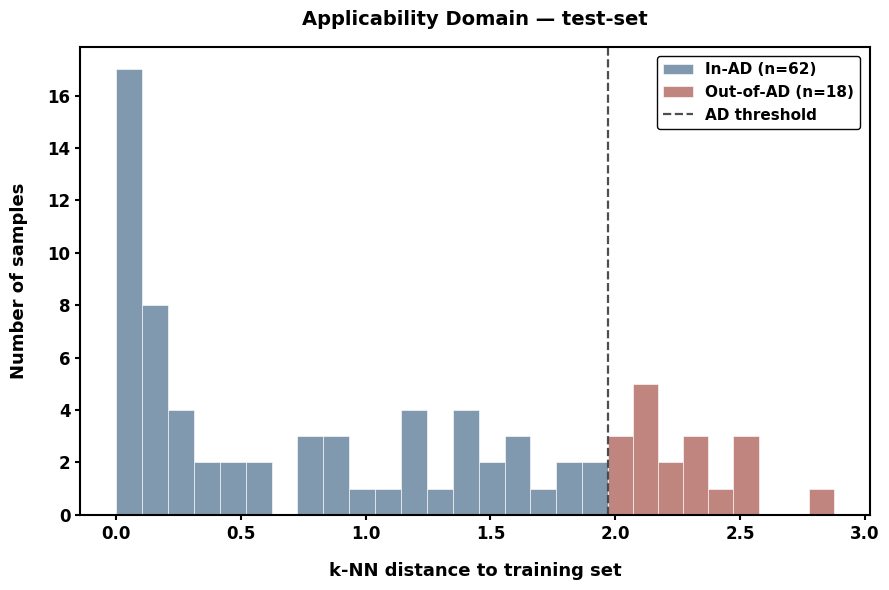

In [ ]:
# =================
# AD Histogram
# =================

fig, ax = plt.subplots(figsize=(9, 6))

COLOR_IN  = "#4A6E8E"
COLOR_OUT = "#A65148"

bins_left  = np.linspace(test_knn_dist.min(), ad_threshold, 20)
bins_right = np.linspace(ad_threshold, test_knn_dist.max(), 10)
bins = np.concatenate([bins_left, bins_right[1:]])

in_ad_dist  = test_knn_dist[in_ad_mask]
out_ad_dist = test_knn_dist[~in_ad_mask]

n_te     = len(test_knn_dist)
n_out_te = int((~in_ad_mask).sum())
n_in_te  = n_te - n_out_te

ax.hist(in_ad_dist, bins=bins,
        color=COLOR_IN, alpha=0.7,
        edgecolor="white", linewidth=0.6,
        label=f"In-AD (n={n_in_te})")

ax.hist(out_ad_dist, bins=bins,
        color=COLOR_OUT, alpha=0.7,
        edgecolor="white", linewidth=0.6,
        label=f"Out-of-AD (n={n_out_te})")

ax.axvline(ad_threshold, linestyle="--", linewidth=1.6,
           color="#444444", alpha=0.95,
           label="AD threshold")

# -------------
# Axis labels
# -------------
ax.set_xlabel("k-NN distance to training set",
              fontsize=13, fontweight="bold", labelpad=14)
ax.set_ylabel("Number of samples",
              fontsize=13, fontweight="bold", labelpad=14)

ax.set_title("Applicability Domain — test-set",
             fontsize=14, fontweight="bold", pad=16)

# -------------
# Tick labels
# -------------
ax.tick_params(axis="both", which="major", labelsize=12, width=1.5)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight("bold")

for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_edgecolor("black")

legend = ax.legend(
    loc="upper right",
    fontsize=11,
    framealpha=0.97,
    borderaxespad=0.6,
)
for text in legend.get_texts():
    text.set_fontweight("bold")
legend.get_frame().set_edgecolor("black")
legend.get_frame().set_linewidth(1)

plt.tight_layout()
plt.savefig("figure_ad_histogram.png", dpi=200, bbox_inches="tight")
plt.show()

## 7.2 AD Radar Comparison Plot


[INFO] In-AD vs Out-of-AD metric breakdown:
   n_in = 62,  n_out = 18
   metric            in-AD   out-AD  Δ
   -------------- -------- --------  ------
   [Presence]
   AUROC             0.930    0.794  +0.137
   AUPRC             0.878    0.733  +0.145
   F1                0.771    0.635  +0.136
   Precision         0.704    0.623  +0.081
   Recall            0.886    0.712  +0.174
   [Abundance]
   cosine            0.797    0.635  +0.163
   1 - TVD           0.654    0.503  +0.152


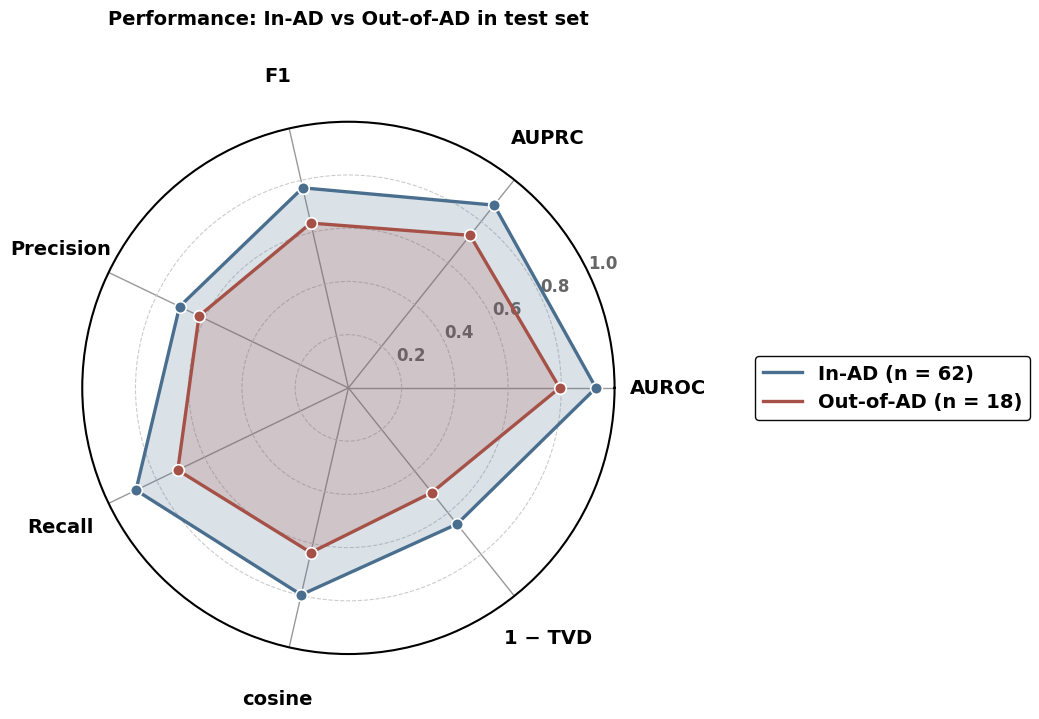

[OK] Figure saved → figure_ad_radar.png


In [ ]:
# ----------------------------------------------------------------
# 1) Subset metric helpers
# ----------------------------------------------------------------

def presence_metrics_subset(Yp_true, Yp_prob, mask):

    Y    = Yp_true[mask]
    P    = Yp_prob[mask]
    Yhat = (P >= 0.5).astype(int)

    aurocs, auprcs = [], []
    for j in range(Y.shape[1]):
        yt = Y[:, j]
        yp = P[:, j]
        if len(np.unique(yt)) < 2:
            continue
        try:
            aurocs.append(roc_auc_score(yt, yp))
            auprcs.append(average_precision_score(yt, yp))
        except ValueError:
            pass

    return {
        "AUROC"    : float(np.mean(aurocs)) if aurocs else np.nan,
        "AUPRC"    : float(np.mean(auprcs)) if auprcs else np.nan,
        "F1"       : f1_score(Y, Yhat, average="macro", zero_division=0),
        "Precision": precision_score(Y, Yhat, average="macro", zero_division=0),
        "Recall"   : recall_score(Y, Yhat, average="macro", zero_division=0),
    }


def abundance_metrics_subset(Ya_true, Ya_pred, mask, eps=1e-12):

    Y = Ya_true[mask]
    P = Ya_pred[mask]

    # --- Cosine ---
    num = (Y * P).sum(axis=1)
    den = np.clip(
        np.linalg.norm(Y, axis=1) * np.linalg.norm(P, axis=1),
        eps, None,
    )
    cosine = float(np.mean(num / den))

    # --- L1 → 1 - TVD (Total Variation Distance) ---
    # TVD = 0.5 * sum|p - q|; here l1_sim = 1 - TVD
    l1     = float(np.mean(np.abs(Y - P).sum(axis=1)))
    l1_sim = max(0.0, 1.0 - l1 / 2.0)

    Yc = np.clip(Y, eps, None)
    Pc = np.clip(P, eps, None)
    Yc = Yc / Yc.sum(axis=1, keepdims=True)
    Pc = Pc / Pc.sum(axis=1, keepdims=True)

    return {
        "cosine" : cosine,
        "l1"     : l1,
        "l1_sim" : l1_sim,
    }


# ----------------------------------------------------------------
# 2) Main radar plot
# ----------------------------------------------------------------

def plot_ad_radar(
    Yp_te,
    P_test_raw,
    Ya_te,
    D_test,
    in_ad_mask,
    X_tr_scaled=None,
    X_te_scaled=None,
    K_NN=5,
    AD_QUANTILE=0.85,
    save_path="figure_ad_radar.png",
):

    # ---- 0) Recompute in_ad_mask if missing ----
    if in_ad_mask is None:
        print("[INFO] in_ad_mask is None in loaded artifacts; "
              "recomputing via k-NN from scaled feature matrices.")
        from sklearn.neighbors import NearestNeighbors

        if X_tr_scaled is None or X_te_scaled is None:
            raise ValueError(
                "in_ad_mask is None AND X_tr_scaled/X_te_scaled were not "
                "provided. Cannot recompute AD."
            )

        nn_train = NearestNeighbors(n_neighbors=K_NN + 1, metric="euclidean")
        nn_train.fit(X_tr_scaled)
        d_tr, _ = nn_train.kneighbors(X_tr_scaled)
        train_knn_dist = d_tr[:, 1:].mean(axis=1)

        nn_test = NearestNeighbors(n_neighbors=K_NN, metric="euclidean")
        nn_test.fit(X_tr_scaled)
        d_te, _ = nn_test.kneighbors(X_te_scaled)
        test_knn_dist = d_te.mean(axis=1)

        ad_threshold = float(np.quantile(train_knn_dist, AD_QUANTILE))
        in_ad_mask   = test_knn_dist <= ad_threshold
        print(f"[INFO] Recomputed AD threshold = {ad_threshold:.4f}  "
              f"(k = {K_NN}, q = {AD_QUANTILE:.2f})")

    # ---- 1) Compute metrics for each subset ----
    out_mask = ~in_ad_mask
    n_in     = int(in_ad_mask.sum())
    n_out    = int(out_mask.sum())

    pm_in  = presence_metrics_subset(Yp_te, P_test_raw, in_ad_mask)
    pm_out = presence_metrics_subset(Yp_te, P_test_raw, out_mask)

    am_in  = abundance_metrics_subset(Ya_te, D_test, in_ad_mask)
    am_out = abundance_metrics_subset(Ya_te, D_test, out_mask)

    # ---- 2) Print sanity table to console ----
    print("\n[INFO] In-AD vs Out-of-AD metric breakdown:")
    print(f"   n_in = {n_in},  n_out = {n_out}")
    print(f"   {'metric':<14} {'in-AD':>8} {'out-AD':>8}  Δ")
    print(f"   {'-'*14} {'-'*8} {'-'*8}  {'-'*6}")
    print("   [Presence]")
    for k in ["AUROC", "AUPRC", "F1", "Precision", "Recall"]:
        delta = pm_in[k] - pm_out[k]
        print(f"   {k:<14} {pm_in[k]:>8.3f} {pm_out[k]:>8.3f}  {delta:+.3f}")
    print("   [Abundance]")
    print(f"   {'cosine':<14} {am_in['cosine']:>8.3f} {am_out['cosine']:>8.3f}  "
          f"{am_in['cosine'] - am_out['cosine']:+.3f}")
    print(f"   {'1 - TVD':<14} {am_in['l1_sim']:>8.3f} {am_out['l1_sim']:>8.3f}  "
          f"{am_in['l1_sim'] - am_out['l1_sim']:+.3f}")

    if n_out < 10:
        print(f"\n   Note: n_out = {n_out} is small; "
              f"out-of-AD AUROC/AUPRC are unstable.")

    # ---- 3) Build score vectors in spoke order -----
    METRICS = [
        "AUROC", "AUPRC", "F1", "Precision", "Recall",
        "cosine", "1 − TVD",
    ]

    def _safe(v):
        return 0.0 if (isinstance(v, float) and np.isnan(v)) else v

    vals_in = [
        _safe(pm_in["AUROC"]),   _safe(pm_in["AUPRC"]),
        _safe(pm_in["F1"]),      _safe(pm_in["Precision"]), _safe(pm_in["Recall"]),
        _safe(am_in["cosine"]),  _safe(am_in["l1_sim"]),
    ]
    vals_out = [
        _safe(pm_out["AUROC"]),  _safe(pm_out["AUPRC"]),
        _safe(pm_out["F1"]),     _safe(pm_out["Precision"]), _safe(pm_out["Recall"]),
        _safe(am_out["cosine"]), _safe(am_out["l1_sim"]),
    ]

    # ---- 4) Polar geometry ----
    N      = len(METRICS)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    vals_in_c  = vals_in  + [vals_in[0]]
    vals_out_c = vals_out + [vals_out[0]]
    angles_c   = angles   + [angles[0]]

    # ---- 5) Figure ----
    fig, ax = plt.subplots(figsize=(10, 9), subplot_kw=dict(polar=True))

    C_IN  = "#4A6E8E"
    C_OUT = "#A65148"

    # In-AD polygon
    ax.plot(angles_c, vals_in_c,
            color=C_IN, linewidth=2.4,
            label=f"In-AD (n = {n_in})",
            zorder=3)
    ax.fill(angles_c, vals_in_c,
            color=C_IN, alpha=0.20, zorder=2)
    ax.scatter(angles, vals_in,
               s=70, color=C_IN, edgecolor="white",
               linewidth=1.2, zorder=4)

    # Out-of-AD polygon
    ax.plot(angles_c, vals_out_c,
            color=C_OUT, linewidth=2.4,
            label=f"Out-of-AD (n = {n_out})",
            zorder=3)
    ax.fill(angles_c, vals_out_c,
            color=C_OUT, alpha=0.20, zorder=2)
    ax.scatter(angles, vals_out,
               s=70, color=C_OUT, edgecolor="white",
               linewidth=1.2, zorder=4)

    # ---- 6) Spoke labels ----
    ax.set_xticks(angles)
    ax.set_xticklabels(METRICS, fontsize=14, fontweight="bold")
    ax.tick_params(axis='x', pad=28)

    # ---- 7) Radial axis ----
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"],
                       fontsize=12, fontweight="bold", color="#666")
    ax.set_rlabel_position(180 / N)

    ax.yaxis.grid(True, color="#CCCCCC", linestyle="--", linewidth=0.8)
    ax.xaxis.grid(True, color="#999999", linestyle="-",  linewidth=1.0)
    ax.spines["polar"].set_linewidth(1.5)
    ax.spines["polar"].set_edgecolor("black")

    # ---- 8) Title & legend ----
    ax.set_title("Performance: In-AD vs Out-of-AD in test set",
                 fontsize=14, fontweight="bold", pad=70)

    legend = ax.legend(
        loc="center left",
        bbox_to_anchor=(1.25, 0.5),
        fontsize=14,
        framealpha=0.97,
        borderaxespad=0.4,
    )
    for text in legend.get_texts():
        text.set_fontweight("bold")
    legend.get_frame().set_edgecolor("black")
    legend.get_frame().set_linewidth(1.0)

    plt.tight_layout()
    # bbox_extra_artists ensures the off-axis legend is not clipped.
    plt.savefig(save_path, dpi=200, bbox_inches="tight",
                bbox_extra_artists=[legend])
    plt.show()
    print(f"[OK] Figure saved → {save_path}")


plot_ad_radar(
    Yp_te       = Yp_te,
    P_test_raw  = P_test_raw,
    Ya_te       = Ya_te,
    D_test      = D_test,
    in_ad_mask  = in_ad_mask,
    X_tr_scaled = X_tr_scaled,
    X_te_scaled = X_te_scaled,
)

# **8 Presence head figures**

## 8.1 PR curve

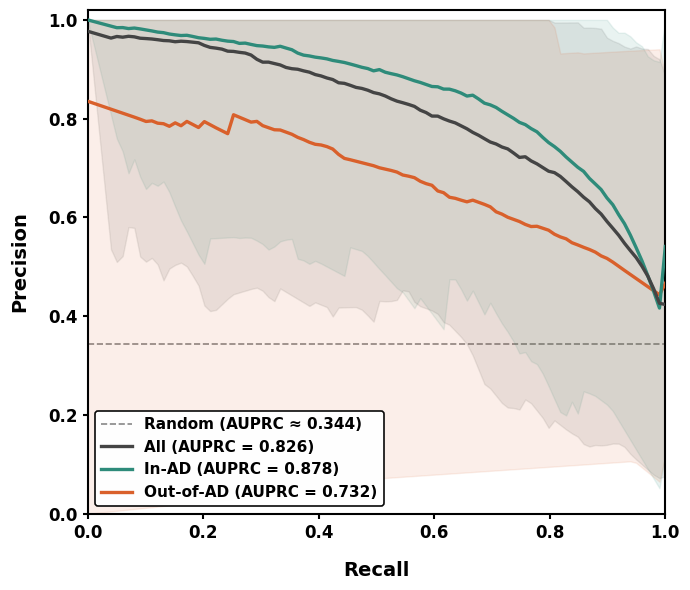

     All:        n_samples=80, n_proteins_used=174
     In-AD:      n_samples=62, n_proteins_used=173
     Out-of-AD:  n_samples=18, n_proteins_used=170


In [ ]:
N_GRID      = 100
RECALL_GRID = np.linspace(0.0, 1.0, N_GRID)
panel_idx   = np.array([i for i, c in enumerate(OUT_COLS) if c != "OTHER"])


def macro_pr_on_subset(sample_mask):
    """Compute macro-averaged PR + 95% CI on a subset of test samples."""
    Yp_sub = Yp_te[sample_mask][:, panel_idx]
    Pp_sub = P_test_raw[sample_mask][:, panel_idx]
    prec_interp, auprc_list = [], []
    for j in range(Yp_sub.shape[1]):
        yt = Yp_sub[:, j].astype(int)
        yp = Pp_sub[:, j]
        if len(np.unique(yt)) < 2:
            continue
        prec_j, rec_j, _ = precision_recall_curve(yt, yp)
        order = np.argsort(rec_j)
        prec_on_grid = np.interp(RECALL_GRID, rec_j[order], prec_j[order])
        prec_interp.append(prec_on_grid)
        auprc_list.append(average_precision_score(yt, yp))

    arr       = np.array(prec_interp)
    mean_prec = arr.mean(axis=0)
    ci_low    = np.percentile(arr,  2.5, axis=0)
    ci_high   = np.percentile(arr, 97.5, axis=0)

    mean_prec = np.clip(mean_prec, 0.0, 1.0)
    ci_low    = np.clip(ci_low,    0.0, 1.0)
    ci_high   = np.clip(ci_high,   0.0, 1.0)

    pos_rate  = float(Yp_sub.mean()) if Yp_sub.size else np.nan
    return mean_prec, ci_low, ci_high, float(np.mean(auprc_list)), len(auprc_list), pos_rate


all_mask = np.ones(len(Yp_te), dtype=bool)
mp_all, lo_all, hi_all, ap_all, n_all, base_all = macro_pr_on_subset(all_mask)
mp_in,  lo_in,  hi_in,  ap_in,  n_in,  base_in  = macro_pr_on_subset(in_ad_mask)
mp_out, lo_out, hi_out, ap_out, n_out, base_out = macro_pr_on_subset(~in_ad_mask)

# ---- Plot ----
fig, ax = plt.subplots(figsize=(7, 6))

# Random baseline = positive rate of the full panel test set
ax.axhline(base_all, linestyle="--", color="#888888",
           linewidth=1.2,
           label=f"Random (AUPRC ≈ {base_all:.3f})", zorder=1)

# Shaded 95% CI bands
ax.fill_between(RECALL_GRID, lo_all, hi_all, color="#444444", alpha=0.10, zorder=2)
ax.fill_between(RECALL_GRID, lo_in,  hi_in,  color="#2E8B7A", alpha=0.10, zorder=2)
ax.fill_between(RECALL_GRID, lo_out, hi_out, color="#D9602B", alpha=0.10, zorder=2)

# Mean curves
ax.plot(RECALL_GRID, mp_all, color="#444444", linewidth=2.4,
        label=f"All (AUPRC = {ap_all:.3f})", zorder=5)
ax.plot(RECALL_GRID, mp_in, color="#2E8B7A", linewidth=2.4,
        label=f"In-AD (AUPRC = {ap_in:.3f})", zorder=4)
ax.plot(RECALL_GRID, mp_out, color="#D9602B", linewidth=2.4,
        label=f"Out-of-AD (AUPRC = {ap_out:.3f})",
        zorder=3)

ax.set_xlabel("Recall",
              fontsize=14, fontweight="bold", labelpad=14)
ax.set_ylabel("Precision",
              fontsize=14, fontweight="bold", labelpad=14)

ax.tick_params(axis="both", which="major", labelsize=12, width=1.5)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight("bold")

for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_edgecolor("black")

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])

legend = ax.legend(loc="lower left", fontsize=11, framealpha=0.97)
for text in legend.get_texts():
    text.set_fontweight("bold")
legend.get_frame().set_edgecolor("black")
legend.get_frame().set_linewidth(1.2)

plt.tight_layout()
plt.savefig("figure_pr_curve.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"     All:        n_samples={int(all_mask.sum())}, n_proteins_used={n_all}")
print(f"     In-AD:      n_samples={int(in_ad_mask.sum())}, n_proteins_used={n_in}")
print(f"     Out-of-AD:  n_samples={int((~in_ad_mask).sum())}, n_proteins_used={n_out}")

## 8.2 ROC curve

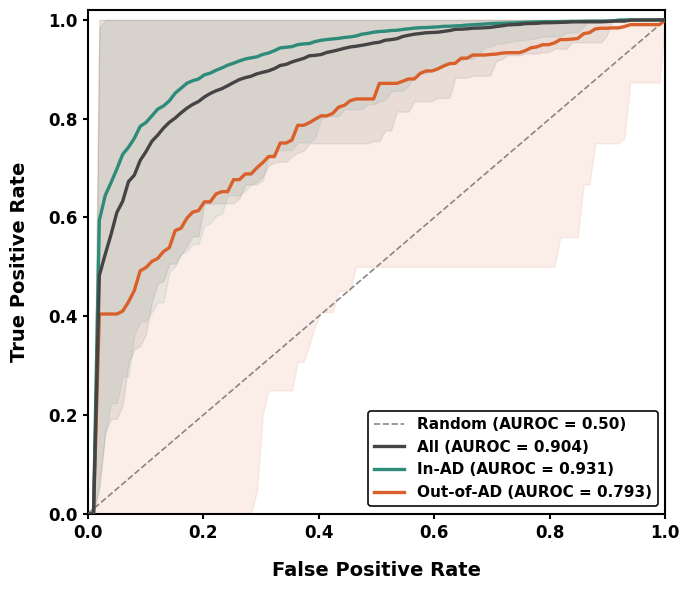

     All:        n_samples=80, n_proteins_used=174
     In-AD:      n_samples=62, n_proteins_used=173
     Out-of-AD:  n_samples=18, n_proteins_used=170


In [ ]:
N_GRID    = 100
FPR_GRID  = np.linspace(0.0, 1.0, N_GRID)
EPS_FORCE = 0.02
panel_idx = np.array([i for i, c in enumerate(OUT_COLS) if c != "OTHER"])


def macro_roc_on_subset(sample_mask):
    """Compute macro-averaged ROC + 95% CI on a subset of test samples."""
    Yp_sub = Yp_te[sample_mask][:, panel_idx]
    Pp_sub = P_test_raw[sample_mask][:, panel_idx]
    tpr_interp, auroc_list = [], []
    for j in range(Yp_sub.shape[1]):
        yt = Yp_sub[:, j].astype(int)
        yp = Pp_sub[:, j]
        if len(np.unique(yt)) < 2:
            continue
        fpr_j, tpr_j, _ = roc_curve(yt, yp)
        # Pad to ensure curve covers [0,0] -> [1,1]
        fpr_j = np.concatenate(([0.0], fpr_j, [1.0]))
        tpr_j = np.concatenate(([0.0], tpr_j, [1.0]))
        tpr_on_grid = np.interp(FPR_GRID, fpr_j, tpr_j)
        tpr_interp.append(tpr_on_grid)
        auroc_list.append(auc(fpr_j, tpr_j))

    arr      = np.array(tpr_interp)
    mean_tpr = arr.mean(axis=0)
    ci_low   = np.percentile(arr,  2.5, axis=0)   # 95% CI lower
    ci_high  = np.percentile(arr, 97.5, axis=0)   # 95% CI upper

    # Clip to valid range
    mean_tpr = np.clip(mean_tpr, 0.0, 1.0)
    ci_low   = np.clip(ci_low,   0.0, 1.0)
    ci_high  = np.clip(ci_high,  0.0, 1.0)

    # Force TPR=0 for very small FPR
    mask = FPR_GRID < EPS_FORCE
    mean_tpr[mask] = 0.0
    ci_low[mask]   = 0.0
    ci_high[mask]  = 0.0

    return mean_tpr, ci_low, ci_high, float(np.mean(auroc_list)), len(auroc_list)


all_mask = np.ones(len(Yp_te), dtype=bool)
mt_all, lo_all, hi_all, auc_all, n_all = macro_roc_on_subset(all_mask)
mt_in,  lo_in,  hi_in,  auc_in,  n_in  = macro_roc_on_subset(in_ad_mask)
mt_out, lo_out, hi_out, auc_out, n_out = macro_roc_on_subset(~in_ad_mask)

# ---- Plot ----
fig, ax = plt.subplots(figsize=(7, 6))

# Diagonal
ax.plot([0, 1], [0, 1], linestyle="--", color="#888888",
        linewidth=1.2, label="Random (AUROC = 0.50)", zorder=1)

# Shaded 95% CI bands (alpha=0.10, matching Project 1)
ax.fill_between(FPR_GRID, lo_all, hi_all, color="#444444", alpha=0.10, zorder=2)
ax.fill_between(FPR_GRID, lo_in,  hi_in,  color="#2E8B7A", alpha=0.10, zorder=2)
ax.fill_between(FPR_GRID, lo_out, hi_out, color="#D9602B", alpha=0.10, zorder=2)

# Mean curves
ax.plot(FPR_GRID, mt_all, color="#444444", linewidth=2.4,
        label=f"All (AUROC = {auc_all:.3f})", zorder=5)
ax.plot(FPR_GRID, mt_in, color="#2E8B7A", linewidth=2.4,
        label=f"In-AD (AUROC = {auc_in:.3f})", zorder=4)
ax.plot(FPR_GRID, mt_out, color="#D9602B", linewidth=2.4,
        label=f"Out-of-AD (AUROC = {auc_out:.3f})",
        zorder=3)

ax.set_xlabel("False Positive Rate",
              fontsize=14, fontweight="bold", labelpad=14)
ax.set_ylabel("True Positive Rate",
              fontsize=14, fontweight="bold", labelpad=14)

ax.tick_params(axis="both", which="major", labelsize=12, width=1.5)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight("bold")

for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_edgecolor("black")

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])

legend = ax.legend(loc="lower right", fontsize=11, framealpha=0.97)
for text in legend.get_texts():
    text.set_fontweight("bold")
legend.get_frame().set_edgecolor("black")
legend.get_frame().set_linewidth(1.2)

plt.tight_layout()
plt.savefig("figure_roc_curve.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"     All:        n_samples={int(all_mask.sum())}, n_proteins_used={n_all}")
print(f"     In-AD:      n_samples={int(in_ad_mask.sum())}, n_proteins_used={n_in}")
print(f"     Out-of-AD:  n_samples={int((~in_ad_mask).sum())}, n_proteins_used={n_out}")

## 8.4 SHAP analysis

In [ ]:
# ============================================================
# PARAMETERS
# ============================================================

RANDOM_SEED             = 42
SHAP_BACKGROUND_SAMPLES = 100
SHAP_DIR                = "shap_results"
os.makedirs(SHAP_DIR, exist_ok=True)

ORDERED_FEATURES = NUMERIC_COLS + ORDINAL_COLS
CATEGORICAL_FEATURES = list(NOMINAL_COLS)
EXPERIMENTAL_FEATURES = {"incub_time", "washing_steps", "agitation","hd_solvent","zp_solvent"}

# ============================================================
# 0) Sanity checks
# ============================================================

required_vars = [
    "final", "device",
    "X_tr_scaled", "X_te_scaled",
    "FEAT_COLS", "OUT_COLS",
]

missing = [v for v in required_vars if v not in globals()]
if missing:
    raise NameError(
        f"Missing required variables: {missing}\n"
        "Please run the load-model cell first."
    )

assert X_tr_scaled.shape[1] == len(FEAT_COLS), \
    f"X_tr_scaled feature dim mismatch: {X_tr_scaled.shape[1]} vs {len(FEAT_COLS)}"
assert X_te_scaled.shape[1] == len(FEAT_COLS), \
    f"X_te_scaled feature dim mismatch: {X_te_scaled.shape[1]} vs {len(FEAT_COLS)}"

final.model.eval()
K_total = len(OUT_COLS)

# ============================================================
# 1) SHAP prediction wrapper
# ============================================================

print("[1/4] Building raw-presence prediction wrapper...")

def predict_presence(X_numpy: np.ndarray) -> np.ndarray:
    final.model.eval()
    with torch.no_grad():
        xb = torch.tensor(X_numpy, dtype=torch.float32, device=device)
        pres_logits, _ = final.model(xb)
        P_raw = torch.sigmoid(pres_logits).cpu().numpy()
    return P_raw

_test_out = predict_presence(X_te_scaled[:3])
assert _test_out.shape == (3, K_total), f"Got {_test_out.shape}"
print(f"      Wrapper output shape OK: {_test_out.shape}")

# ============================================================
# 2) Compute SHAP values
# ============================================================

print("[2/4] Computing SHAP values...")

rng        = np.random.default_rng(RANDOM_SEED)
bg_idx     = rng.choice(len(X_tr_scaled),
                        size=min(SHAP_BACKGROUND_SAMPLES, len(X_tr_scaled)),
                        replace=False)
background = X_tr_scaled[bg_idx]

explainer        = shap.Explainer(predict_presence, background,
                                  seed=RANDOM_SEED)
shap_obj         = explainer(X_te_scaled)
shap_array       = shap_obj.values
shap_all_encoded = [shap_array[:, :, k] for k in range(K_total)]

print(f"      SHAP array shape: {shap_array.shape}")

# ============================================================
# 3) Aggregate one-hot SHAP back to original features
# ============================================================

print("[3/4] Aggregating one-hot SHAP back to original features...")

X_test_encoded = pd.DataFrame(X_te_scaled, columns=FEAT_COLS)

def build_feature_groups(encoded_columns):
    encoded_columns = list(encoded_columns)
    groups = {}
    for col in ORDERED_FEATURES:
        if col in encoded_columns:
            groups[col] = [col]
    for col in CATEGORICAL_FEATURES:
        matched = [c for c in encoded_columns if c.startswith(col + "_")]
        if matched:
            groups[col] = matched
    return groups

feature_groups = build_feature_groups(X_test_encoded.columns)
original_feats = list(feature_groups.keys())
print(f"      Recovered {len(original_feats)} original features: {original_feats}")

aggregated_shap_list = []
for k in range(K_total):
    shap_vals = shap_all_encoded[k]
    cols_agg  = []
    for feat in original_feats:
        idx = [X_test_encoded.columns.get_loc(c) for c in feature_groups[feat]]
        cols_agg.append(shap_vals[:, idx].sum(axis=1))
    aggregated_shap_list.append(np.stack(cols_agg, axis=1))

agg_X_cols = {}
for feat in original_feats:
    cols = feature_groups[feat]
    if len(cols) == 1:
        agg_X_cols[feat] = X_test_encoded[cols[0]].values
    else:
        agg_X_cols[feat] = np.argmax(X_test_encoded[cols].values, axis=1)
X_test_agg = pd.DataFrame(agg_X_cols, index=X_test_encoded.index)

heatmap_rows    = [np.abs(aggregated_shap_list[k]).mean(axis=0) for k in range(K_total)]
heatmap_df      = pd.DataFrame(heatmap_rows, index=OUT_COLS, columns=original_feats)
global_mean     = heatmap_df.mean(axis=0).sort_values(ascending=False)
sorted_features = global_mean.index.tolist()
heatmap_df      = heatmap_df[sorted_features]
X_test_agg      = X_test_agg[sorted_features]

# ============================================================
# 4) Save
# ============================================================

print("[4/4] Saving SHAP results...")

plot_data = {
    "heatmap_df"            : heatmap_df,
    "shap_all"              : aggregated_shap_list,
    "X_test"                : X_test_agg,
    "sorted_features"       : sorted_features,
    "selected_targets"      : list(OUT_COLS),
    "feature_groups"        : feature_groups,
    "shap_all_encoded"      : shap_all_encoded,
    "X_test_encoded"        : X_test_encoded,
    "encoded_feature_names" : list(X_test_encoded.columns),
    "experimental_features" : list(EXPERIMENTAL_FEATURES),
}

pkl_path = os.path.join(SHAP_DIR, "shap_full_data.pkl")
with open(pkl_path, "wb") as f:
    pickle.dump(plot_data, f)
print(f"      ✓ Saved → {pkl_path}")

max_val  = heatmap_df.values.max()
xlsx_path = os.path.join(SHAP_DIR, "shap_heatmap_full.xlsx")
(heatmap_df / max_val * 100).round(2).T.to_excel(xlsx_path)
print(f"      ✓ Exported heatmap → {xlsx_path}")

print("\n✅ SHAP computation complete.")
print(f"   N_test = {len(X_test_encoded)}, K_total = {K_total}, F_orig = {len(original_feats)}")

[1/4] Building raw-presence prediction wrapper...
      Wrapper output shape OK: (3, 175)
[2/4] Computing SHAP values...
      SHAP array shape: (80, 55, 175)
[3/4] Aggregating one-hot SHAP back to original features...
      Recovered 12 original features: ['size_nm', 'zp_mv', 'incub_time', 'washing_steps', 'mod_type', 'mod_charge', 'np_type', 'np_subtype', 'zp_charge', 'zp_solvent', 'hd_solvent', 'agitation']
[4/4] Saving SHAP results...
      ✓ Saved → shap_results/shap_full_data.pkl
      ✓ Exported heatmap → shap_results/shap_heatmap_full.xlsx

✅ SHAP computation complete.
   N_test = 80, K_total = 175, F_orig = 12


### SHAP heatmap

[1/3] Loading saved SHAP data...
      Selected 30 proteins × 12 features
[2/3] Querying UniProt for protein names...

      Accession  Label
      ---------- --------------------------------------------------
      P03952     Plasma kallikrein
      P05546     Heparin cofactor 2
      P02790     Hemopexin
      P02775     Platelet basic protein
      P02788     Lactotransferrin
      P00747     Plasminogen
      P49908     Selenoprotein P
      P69905     Hemoglobin subunit alpha
      P03951     Coagulation factor XI
      Q9Y490     Talin-1
      P12259     Coagulation factor V
      O14791     Apolipoprotein L1
      P07996     Thrombospondin-1
      P68871     Hemoglobin subunit beta
      P02765     Alpha-2-HS-glycoprotein
      P15169     Carboxypeptidase N catalytic chain
      P02655     Apolipoprotein C-II
      P18065     Insulin-like growth factor-binding protein 2
      P13671     Complement component C6
      P17936     Insulin-like growth factor-binding protein 3
      P

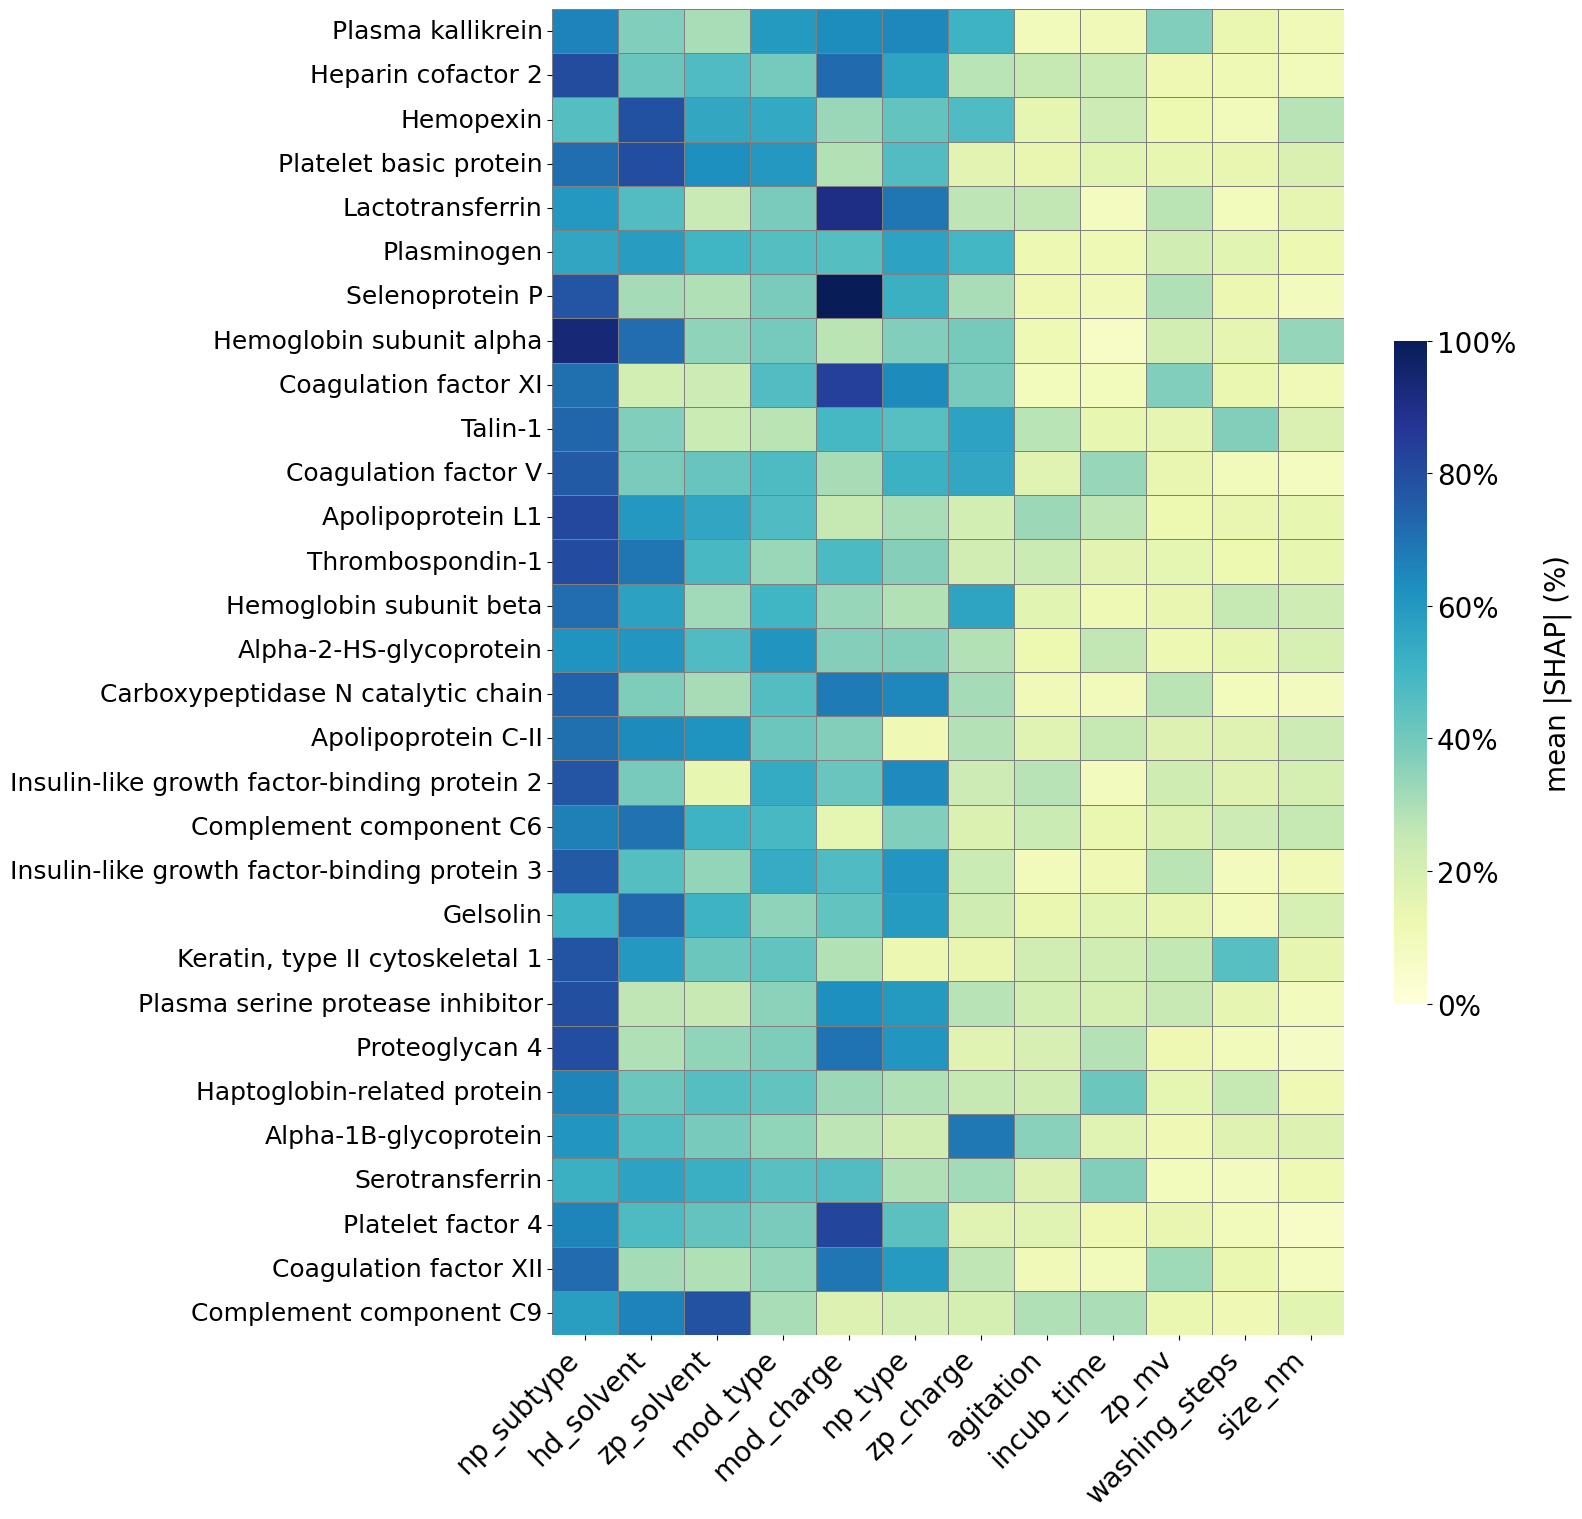


✅ Heatmap saved → shap_results/shap_heatmap_top30.png


In [ ]:
def fetch_uniprot_names(accessions, batch_size=100, timeout=30):
    base = "https://rest.uniprot.org/uniprotkb/accessions"
    out  = {}

    for i in range(0, len(accessions), batch_size):
        chunk = accessions[i:i + batch_size]
        params = {
            "accessions": ",".join(chunk),
            "fields"    : "accession,gene_primary,protein_name",
            "format"    : "json",
        }
        r = requests.get(base, params=params, timeout=timeout)
        r.raise_for_status()
        data = r.json()

        for entry in data.get("results", []):
            acc = entry.get("primaryAccession")

            # primary gene name (may be absent for some Ig fragments)
            gene = None
            genes = entry.get("genes", [])
            if genes and genes[0].get("geneName"):
                gene = genes[0]["geneName"].get("value")

            # recommended protein full name (fall back to submitted name)
            protein = None
            desc = entry.get("proteinDescription", {})
            rec  = desc.get("recommendedName")
            if rec and rec.get("fullName"):
                protein = rec["fullName"].get("value")
            elif desc.get("submissionNames"):
                protein = desc["submissionNames"][0]["fullName"].get("value")

            out[acc] = {"gene": gene, "protein": protein}

    return out


def make_label(acc, info, style="gene_protein"):
    """
    Build a y-axis label from the lookup result.

    style options:
      "gene"          -> "PLG"
      "gene_protein"  -> "PLG (Plasminogen)"
      "protein"       -> "Plasminogen"
      "acc_gene"      -> "P00747 | PLG"
    Falls back to the raw accession if no name was found.
    """
    if info is None:
        return acc
    gene, protein = info.get("gene"), info.get("protein")

    if style == "gene":
        return gene or acc
    if style == "protein":
        return protein or acc
    if style == "acc_gene":
        return f"{acc} | {gene}" if gene else acc
    # default: gene_protein
    if gene and protein:
        return f"{gene} ({protein})"
    return gene or protein or acc


# ============================================================
# Plot heatmap
# ============================================================

SUBSET_N_PROTEINS = 30
SUBSET_N_FEATURES = 13
LABEL_STYLE       = "protein"

# ============================================================
# HEATMAP FUNCTION
# ============================================================

def plot_heatmap_subset(heatmap_subset, id_to_label=None,
                        save_path=None, dpi=600):

    max_val = heatmap_subset.values.max()
    if max_val == 0 or np.isnan(max_val):
        print("⚠️ Heatmap max is zero or NaN. Skip plotting.")
        return

    heatmap_pct = heatmap_subset / max_val * 100.0

    if id_to_label is not None:
        heatmap_pct = heatmap_pct.rename(index=id_to_label)

    def to_percent(x, _):
        return f"{x:.0f}%"

    n_proteins = len(heatmap_subset)
    n_features = len(heatmap_subset.columns)

    fig_height = max(12, n_proteins * 0.65)
    fig_width  = max(18, n_features * 0.9)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    sns_ax = sns.heatmap(
        heatmap_pct,
        ax           = ax,
        cmap         = "YlGnBu",
        linewidths   = 0.4,
        linecolor    = "gray",
        annot        = False,
        square       = False,
        vmin         = 0,
        vmax         = 100,
        cbar_kws     = {
            "shrink": 0.5,
            "format": FuncFormatter(to_percent),
            "label" : "mean |SHAP| (%)",
        },
    )

    cbar = sns_ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=20)
    cbar.set_label("mean |SHAP| (%)", fontsize=20, labelpad=20)

    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right",
                       fontsize=20)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=18)

    # Long protein names need extra room on the left.
    plt.subplots_adjust(left=0.35, bottom=0.2)

    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight", pad_inches=0.2)

    plt.show()


# ============================================================
# MAIN
# ============================================================

def load_shap_data_and_plot_heatmaps():
    print("[1/3] Loading saved SHAP data...")
    pkl_path = os.path.join("shap_results", "shap_full_data.pkl")
    with open(pkl_path, "rb") as f:
        plot_data = pickle.load(f)

    heatmap_df       = plot_data["heatmap_df"]
    sorted_features  = plot_data["sorted_features"]
    selected_targets = plot_data["selected_targets"]

    # Sort proteins by their global mean |SHAP| value
    protein_importance = heatmap_df.mean(axis=1).sort_values(ascending=False)
    top_proteins       = protein_importance.index[:SUBSET_N_PROTEINS].tolist()
    top_features       = sorted_features[:SUBSET_N_FEATURES]

    heatmap_subset = heatmap_df.loc[top_proteins, top_features]

    print(f"      Selected {len(top_proteins)} proteins × "
          f"{len(top_features)} features")

    # ---- Resolve accession IDs -> protein names ----
    print("[2/3] Querying UniProt for protein names...")
    lookup = fetch_uniprot_names(top_proteins)
    id_to_label = {acc: make_label(acc, lookup.get(acc), style=LABEL_STYLE)
                   for acc in top_proteins}

    print(f"\n      {'Accession':<10} {'Label'}")
    print(f"      {'-'*10} {'-'*50}")
    for acc in top_proteins:
        print(f"      {acc:<10} {id_to_label[acc]}")

    print("\n[3/3] Plotting heatmap...")
    save_path = os.path.join(
        SHAP_DIR,
        f"shap_heatmap_top{SUBSET_N_PROTEINS}.png",
    )
    plot_heatmap_subset(heatmap_subset, id_to_label=id_to_label,
                        save_path=save_path)

    print(f"\n✅ Heatmap saved → {save_path}")


load_shap_data_and_plot_heatmaps()

### SHAP summary plot

In [ ]:
# ============================================================
# PARAMETERS
# ============================================================

EXPERIMENTAL_FEATURES = {
    "incub_time",
    "washing_steps",
    "agitation",
    "hd_solvent",
    "zp_solvent",
}


CONTINUOUS_ORDERED_FEATURES = NUMERIC_COLS + ORDINAL_COLS

NOMINAL_FEATURES = list(NOMINAL_COLS)

RANDOM_SEED         = 42
MAX_POINTS_FOR_PLOT = 2500


# ============================================================
# LOAD DATA
# ============================================================

print("[Loading SHAP data]")
pkl_path = os.path.join("shap_results", "shap_full_data.pkl")
with open(pkl_path, "rb") as f:
    plot_data = pickle.load(f)

print(f"   K = {len(plot_data['shap_all'])}, "
      f"N_test = {len(plot_data['X_test'])}")


def _get_4color_diverging():

    colors = [
        (0.0,  "#1f5fa8"),
        (0.33, "#7fb3de"),
        (0.66, "#f4a460"),
        (1.0,  "#c43c2e"),
    ]
    cmap = LinearSegmentedColormap.from_list("blue_orange_4", colors)
    norm = TwoSlopeNorm(vmin=0, vcenter=0.5, vmax=1)
    return cmap, norm


def _draw_manual_left_labels(ax, labels, x_pos, fontsize=14, fontweight="bold"):
    for i, lab in enumerate(labels):
        ax.text(
            x_pos, i, lab,
            va="center", ha="right",
            fontsize=fontsize,
            fontweight=fontweight,
            color="black",
            zorder=10,
            clip_on=False
        )


def _stylize_spines(ax, linewidth=2.0):
    for s in ax.spines.values():
        s.set_visible(True)
        s.set_color("black")
        s.set_linewidth(linewidth)


def _build_concat_scatter_data(shap_list, X_values, max_points):
    K = len(shap_list)

    shap_concat = np.concatenate(shap_list, axis=0)
    X_concat    = np.tile(X_values, (K, 1))

    n_total = shap_concat.shape[0]
    if n_total > max_points:
        rng = np.random.default_rng(RANDOM_SEED)
        idx = rng.choice(n_total, size=max_points, replace=False)
        shap_concat = shap_concat[idx]
        X_concat    = X_concat[idx]

    return shap_concat, X_concat


# ============================================================
# SHARED SCATTER CORE
# ============================================================

def _scatter_summary_core(
    shap_matrix, X_color_matrix, feature_names, feature_group_for_color,
    xlabel, save_path,
    point_size=18,
    point_alpha=0.55,
    jitter_scale=0.10,
    bar_height=0.72,
    dpi=600,
    fig_width=15,
    fig_height_per_feature=0.50,
    min_fig_height=6,
    vertical_margin=0.50,
    left_margin=0.30,
    right_margin=0.96,
    top_margin=0.92,
    bottom_margin=0.12,
):
    raw_mean_vals = np.abs(shap_matrix).mean(axis=0)
    percent_vals  = raw_mean_vals / raw_mean_vals.sum() * 100.0
    order_idx       = np.argsort(raw_mean_vals)[::-1]
    feature_names   = [feature_names[i] for i in order_idx]
    raw_mean_vals   = raw_mean_vals[order_idx]
    percent_vals    = percent_vals[order_idx]
    shap_matrix     = shap_matrix[:, order_idx]
    X_color_matrix  = X_color_matrix[:, order_idx]

    scaler = MinMaxScaler()
    X_color_scaled = scaler.fit_transform(X_color_matrix)

    cmap, norm = _get_4color_diverging()

    bar_colors = [
        "#9e9ac8" if feature_group_for_color.get(f) == "experimental"
        else "#a1d99b"
        for f in feature_names
    ]

    shap_max    = np.abs(shap_matrix).max() * 1.1
    total_limit = max(0.05, shap_max)
    bar_max     = raw_mean_vals.max() * 1.18

    n_feat     = len(feature_names)
    fig_height = max(min_fig_height, n_feat * fig_height_per_feature)

    fig = plt.figure(figsize=(fig_width, fig_height))
    gs  = gridspec.GridSpec(1, 2, width_ratios=[26, 0.7], wspace=0.20)

    ax  = fig.add_subplot(gs[0])
    ax2 = ax.twiny()

    ax2.set_zorder(0)
    ax.set_zorder(2)
    ax.patch.set_alpha(0.0)
    ax2.patch.set_alpha(0.0)

    # ---------------- Bars ----------------
    text_x = bar_max * 0.015

    for i, (fi, pct, color) in enumerate(zip(raw_mean_vals, percent_vals, bar_colors)):
        ax2.barh(
            i, fi,
            height=bar_height,
            color=color,
            alpha=0.40,
            edgecolor="none",
            zorder=1
        )

        ax2.text(
            text_x, i,
            f"{fi:.3f} ({pct:.1f}%)",
            va="center",
            ha="left",
            fontsize=12,
            fontweight="bold",
            color="black",
            zorder=3
        )

    # ---------------- Scatter ----------------
    rng = np.random.default_rng(RANDOM_SEED)

    for i in range(n_feat):
        s_i      = shap_matrix[:, i]
        c_i      = X_color_scaled[:, i]
        y_jitter = rng.normal(loc=0, scale=jitter_scale, size=s_i.shape[0])

        ax.scatter(
            s_i, i + y_jitter,
            c=c_i,
            cmap=cmap,
            norm=norm,
            alpha=point_alpha,
            s=point_size,
            zorder=4,
            linewidth=0
        )

    # ---------------- Y axis ----------------
    y_pos = np.arange(n_feat)
    ax.set_yticks(y_pos)
    ax.set_yticklabels([""] * n_feat)

    ax.tick_params(axis="y", which="both", left=False, labelleft=False)
    ax2.set_yticks([])
    ax2.tick_params(
        axis="y", which="both",
        left=False, right=False,
        labelleft=False,
        labelright=False
    )

    # Most important feature stays on top
    ax.set_ylim(n_feat - 1 + vertical_margin, -vertical_margin)
    ax2.set_ylim(n_feat - 1 + vertical_margin, -vertical_margin)

    # ---------------- X axes ----------------
    ax.set_xlim(-total_limit, total_limit)
    ax.set_xlabel(
        xlabel,
        fontsize=18,
        fontweight="bold",
        labelpad=22
    )

    ax.axvline(
        x=0,
        linestyle="--",
        color="gray",
        linewidth=1.2,
        alpha=0.7
    )

    ax.tick_params(axis="x", labelsize=14, width=1.5, length=6)
    for tlab in ax.get_xticklabels():
        tlab.set_fontweight("bold")

    ax2.set_xlim(0, bar_max)
    ax2.set_xlabel(
        "Mean |SHAP|",
        fontsize=15,
        fontweight="bold",
        labelpad=16
    )

    ax2.tick_params(axis="x", labelsize=14, width=1.5, length=6)
    for tlab in ax2.get_xticklabels():
        tlab.set_fontweight("bold")

    _stylize_spines(ax, linewidth=2.0)

    # ---------------- Manual left labels ----------------
    manual_label_x = -total_limit * 1.06
    _draw_manual_left_labels(
        ax,
        feature_names,
        manual_label_x,
        fontsize=16,
        fontweight="bold"
    )

    # ---------------- Colorbar ----------------
    cax  = fig.add_subplot(gs[1])
    sm   = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([0, 1])

    cbar = plt.colorbar(sm, cax=cax)
    cbar.set_label(
        "Feature value",
        fontsize=15,
        fontweight="bold",
        labelpad=18
    )

    cbar.ax.tick_params(labelsize=13, width=1.5, length=5)
    for tlab in cbar.ax.get_yticklabels():
        tlab.set_fontweight("bold")

    cbar.outline.set_linewidth(1.5)
    cbar.outline.set_edgecolor("black")

    # ---------------- Legend (bottom-right) ----------------
    from matplotlib.patches import Patch

    legend_handles = [
        Patch(facecolor="#9e9ac8", edgecolor="none",
              label="Experimental Conditions"),
        Patch(facecolor="#a1d99b", edgecolor="none",
              label="NP Physicochemical Properties"),
    ]

    ax.legend(
        handles=legend_handles,
        loc="lower right",
        bbox_to_anchor=(1.0, 0.0),
        frameon=True,
        edgecolor="black",      # 只有外框黑色
        framealpha=1.0,
        fontsize=10,            # 字体调小
        borderpad=0.5,
        labelspacing=0.3,
        handlelength=1.0,
        handleheight=1.0,
        handletextpad=0.5,
    ).set_zorder(20)

    fig.subplots_adjust(
        left=left_margin,
        right=right_margin,
        top=top_margin,
        bottom=bottom_margin
    )

    fig.savefig(save_path, dpi=dpi, bbox_inches="tight", pad_inches=0.30)
    plt.show()

    print(f"   ✓ Saved → {save_path}")

[Loading SHAP data]
   K = 175, N_test = 80


**Continuous feature SHAP summary plot**

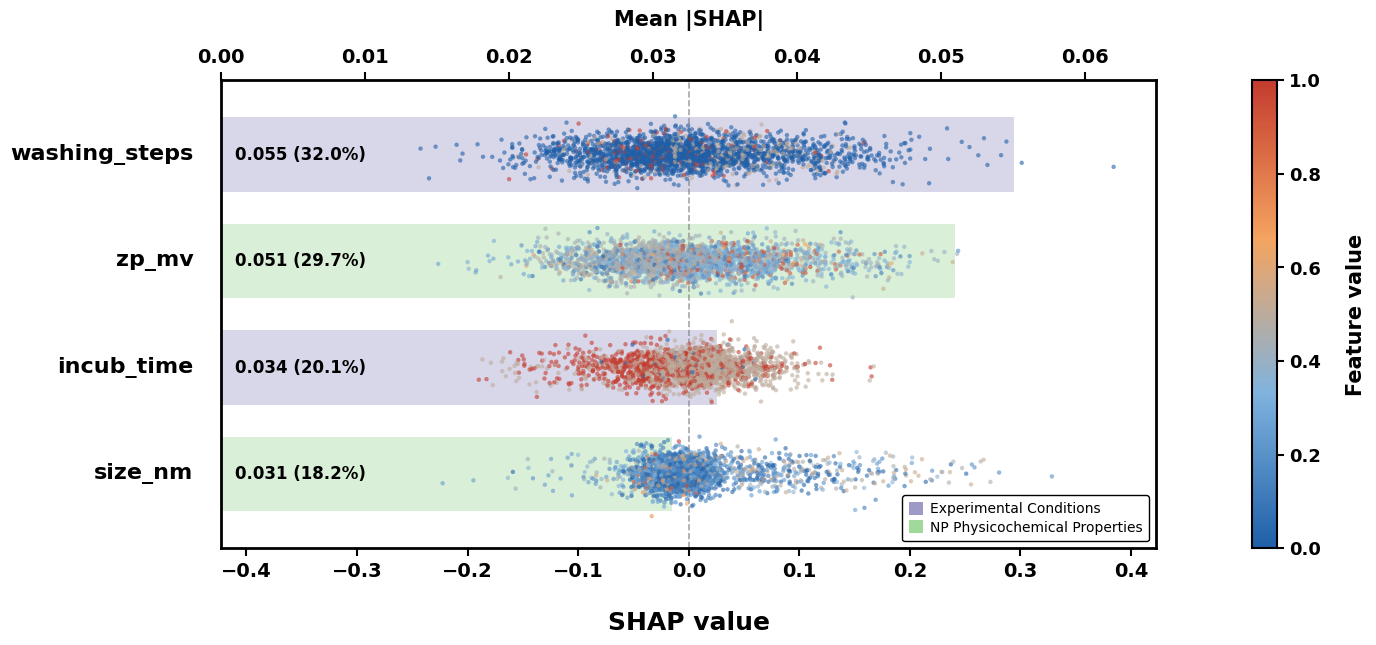

   ✓ Saved → shap_results/continuous_feature_scatter.png


In [ ]:
# ============================================================
# Continuous / Ordinal Features
# ============================================================

def plot_continuous_scatter_concat(plot_data, save_path, dpi=600):
    shap_all_agg = plot_data["shap_all"]
    X_test_agg   = plot_data["X_test"]

    feats = [
        f for f in CONTINUOUS_ORDERED_FEATURES
        if f in X_test_agg.columns
    ]

    feat_idx = [list(X_test_agg.columns).index(f) for f in feats]

    shap_subset = [s[:, feat_idx] for s in shap_all_agg]
    X_values    = X_test_agg[feats].values

    shap_mat, X_mat = _build_concat_scatter_data(
        shap_subset,
        X_values,
        MAX_POINTS_FOR_PLOT
    )

    feat_group_map = {
        f: ("experimental" if f in EXPERIMENTAL_FEATURES else "np")
        for f in feats
    }

    _scatter_summary_core(
        shap_matrix             = shap_mat,
        X_color_matrix          = X_mat,
        feature_names           = list(feats),
        feature_group_for_color = feat_group_map,
        xlabel                  = "SHAP value",
        save_path               = save_path,

        point_size              = 10,
        point_alpha             = 0.6,
        jitter_scale            = 0.099,
        bar_height              = 0.7,

        dpi                     = dpi,
        fig_width               = 16,
        fig_height_per_feature  = 0.6,
        min_fig_height          = 6.5,
        vertical_margin         = 0.7,
        left_margin             = 0.30,
        right_margin            = 0.96,
        top_margin              = 0.88,
        bottom_margin           = 0.16,
    )


plot_continuous_scatter_concat(
    plot_data,
    save_path=os.path.join("shap_results", "continuous_feature_scatter.png"),
)

**Categorical features (TOP 10) SHAP summary plot**

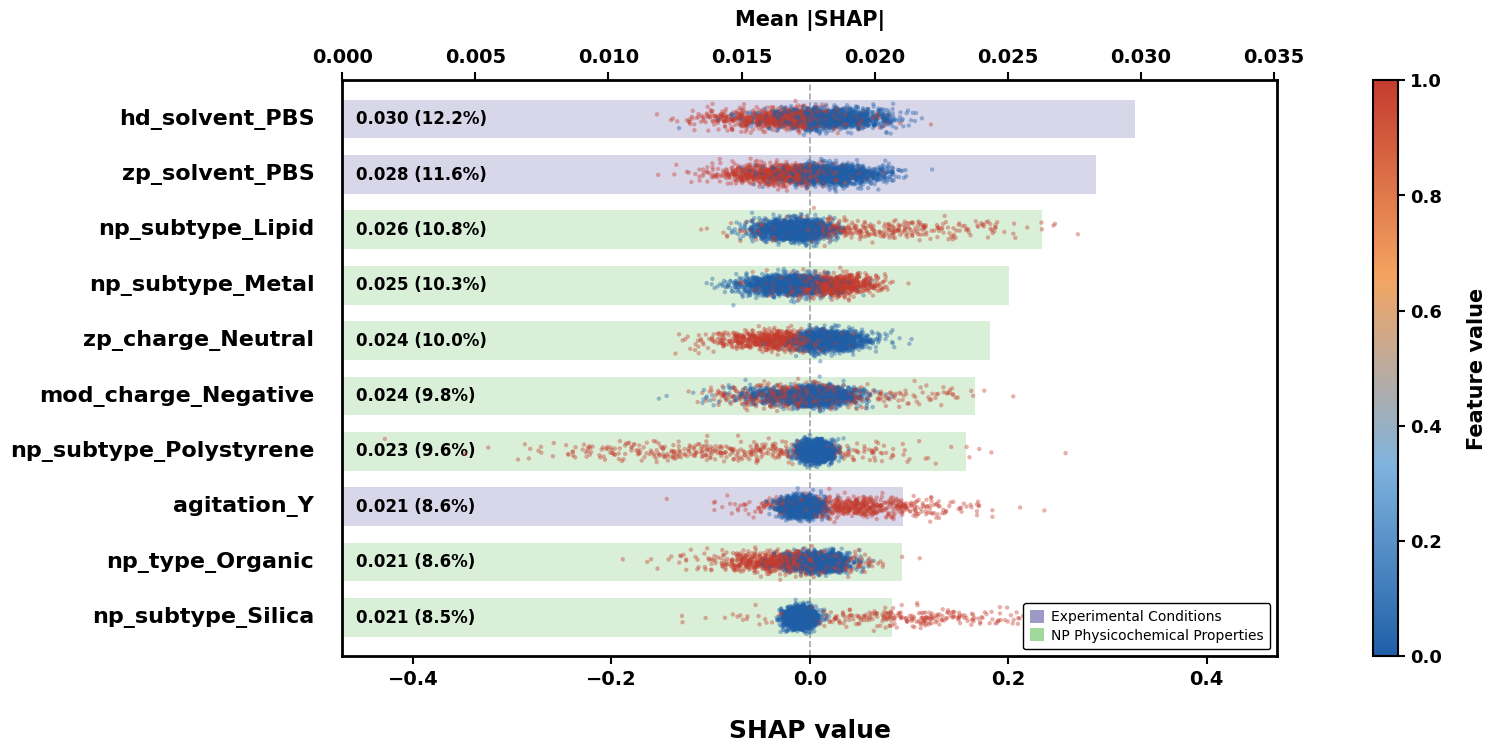

   ✓ Saved → shap_results/nominal_feature_scatter_top10.png


In [ ]:
# ============================================================
# Categorical Features (TOP 15 ONLY)
# ============================================================

EXPERIMENTAL_FEATURES = {
    "incub_time",
    "washing_steps",
    "agitation",
    "hd_solvent",
    "zp_solvent",
}


def plot_nominal_onehot_scatter_concat_top10(plot_data, save_path, dpi=600, top_n=10):
    shap_all_encoded = plot_data["shap_all_encoded"]
    X_test_encoded   = plot_data["X_test_encoded"]
    feature_groups   = plot_data["feature_groups"]

    sub_cols = []
    for fname in NOMINAL_FEATURES:
        if fname in feature_groups:
            sub_cols.extend(feature_groups[fname])

    if not sub_cols:
        print("⚠️ No nominal subcolumns found — skipping.")
        return

    col_idx     = [X_test_encoded.columns.get_loc(c) for c in sub_cols]
    shap_subset = [s[:, col_idx] for s in shap_all_encoded]
    X_values    = X_test_encoded[sub_cols].values.astype(float)

    shap_mat, X_mat = _build_concat_scatter_data(
        shap_subset,
        X_values,
        MAX_POINTS_FOR_PLOT
    )

    parent_lookup = {}
    for parent, children in feature_groups.items():
        for c in children:
            parent_lookup[c] = parent

    feat_group_map = {
        c: (
            "experimental"
            if parent_lookup.get(c) in EXPERIMENTAL_FEATURES
            else "np"
        )
        for c in sub_cols
    }

    # ========================================================
    # Only keep top N features by mean |SHAP|
    # ========================================================
    raw_mean_vals = np.abs(shap_mat).mean(axis=0)
    top_idx = np.argsort(raw_mean_vals)[::-1][:top_n]

    shap_mat_top = shap_mat[:, top_idx]
    X_mat_top    = X_mat[:, top_idx]
    sub_cols_top = [sub_cols[i] for i in top_idx]

    feat_group_map_top = {c: feat_group_map[c] for c in sub_cols_top}

    _scatter_summary_core(
        shap_matrix             = shap_mat_top,
        X_color_matrix          = X_mat_top,
        feature_names           = list(sub_cols_top),
        feature_group_for_color = feat_group_map_top,
        xlabel                  = "SHAP value",
        save_path               = save_path,

        # ---- only display tuning ----

        point_size              = 10,
        point_alpha             = 0.4,
        jitter_scale            = 0.09,
        bar_height              = 0.7,

        dpi                     = dpi,
        fig_width               = 16,

        # ---- margin / spacing ----
        fig_height_per_feature  = 0.4,
        min_fig_height          = 8,
        vertical_margin         = 0.7,
        left_margin             = 0.30,
        right_margin            = 0.96,
        top_margin              = 0.88,
        bottom_margin           = 0.16,
    )


plot_nominal_onehot_scatter_concat_top10(
    plot_data,
    save_path=os.path.join("shap_results", "nominal_feature_scatter_top10.png"),
    top_n=10
)

**Global categorical features importance plot**

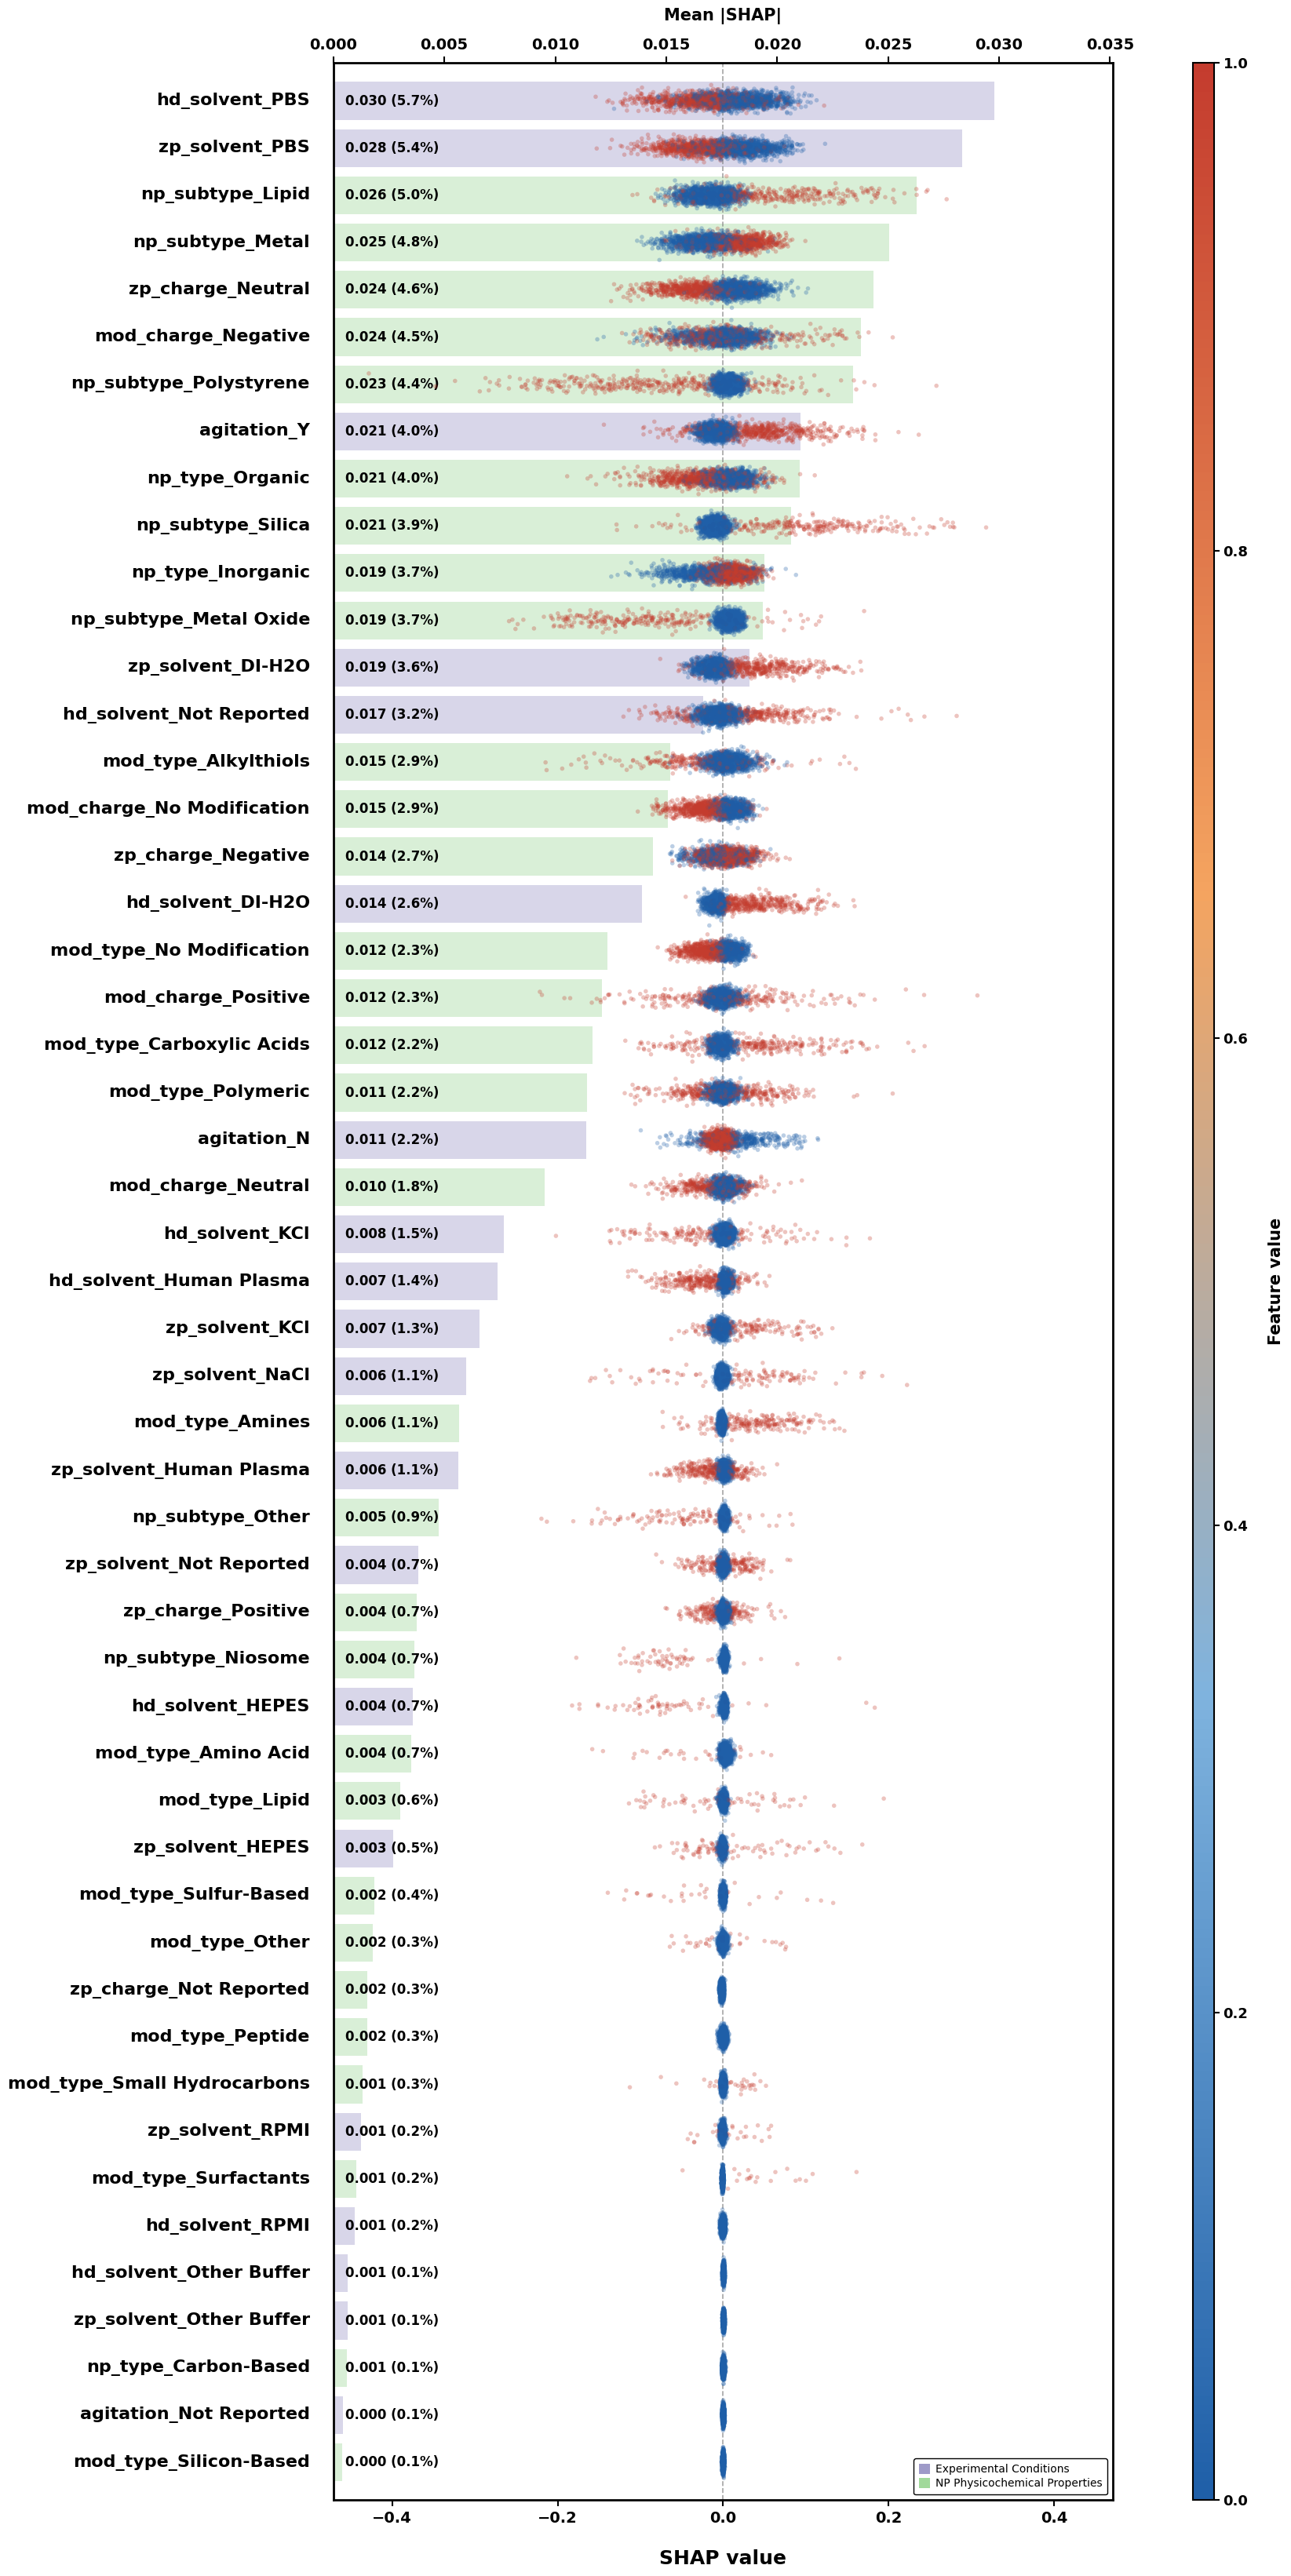

   ✓ Saved → shap_results/nominal_feature_scatter.png


In [ ]:
# ============================================================
# Global Categorical Features
# ============================================================

def plot_nominal_onehot_scatter_concat(plot_data, save_path, dpi=600):
    shap_all_encoded = plot_data["shap_all_encoded"]
    X_test_encoded   = plot_data["X_test_encoded"]
    feature_groups   = plot_data["feature_groups"]

    sub_cols = []

    for fname in NOMINAL_FEATURES:
        if fname in feature_groups:
            sub_cols.extend(feature_groups[fname])

    if not sub_cols:
        print("⚠️ No nominal subcolumns found — skipping.")
        return

    col_idx     = [X_test_encoded.columns.get_loc(c) for c in sub_cols]
    shap_subset = [s[:, col_idx] for s in shap_all_encoded]
    X_values    = X_test_encoded[sub_cols].values.astype(float)

    shap_mat, X_mat = _build_concat_scatter_data(
        shap_subset,
        X_values,
        MAX_POINTS_FOR_PLOT
    )

    parent_lookup = {}
    for parent, children in feature_groups.items():
        for c in children:
            parent_lookup[c] = parent

    feat_group_map = {
        c: (
            "experimental"
            if parent_lookup.get(c) in EXPERIMENTAL_FEATURES
            else "np"
        )
        for c in sub_cols
    }

    _scatter_summary_core(
        shap_matrix             = shap_mat,
        X_color_matrix          = X_mat,
        feature_names           = list(sub_cols),
        feature_group_for_color = feat_group_map,
        xlabel                  = "SHAP value",
        save_path               = save_path,

        # ---- only display tuning ----
        point_size              = 16,
        point_alpha             = 0.3,
        jitter_scale            = 0.092,
        bar_height              = 0.8,

        dpi                     = dpi,
        fig_width               = 17,

        # ---- margin / spacing ----
        fig_height_per_feature  = 0.7,
        min_fig_height          = 14,
        vertical_margin         = 0.8,

        left_margin             = 0.30,
        right_margin            = 0.96,
        top_margin              = 0.95,
        bottom_margin           = 0.08,
    )


plot_nominal_onehot_scatter_concat(
    plot_data,
    save_path=os.path.join("shap_results", "nominal_feature_scatter.png"),
)

# **9 Abundance head figures**

## 9.1 Per-protein analysis

In [ ]:
# ---- Build per_prot_df for downstream plotting cells ----
K_total = Ya_te.shape[1]

# Recompute per_prot_pearson if not available
_r = np.full(K_total, np.nan)
for j in range(K_total):
    yt, yp = Ya_te[:, j], D_test[:, j]
    if yt.std() > 1e-8 and yp.std() > 1e-8:
        _r[j], _ = pearsonr(yt, yp)

panel_mean_abund = Ya_tr[:, np.arange(K_total - 1)].mean(axis=0)
other_mean       = Ya_tr[:, K_total - 1].mean()

per_prot_df = pd.DataFrame({
    "protein"           : OUT_COLS,
    "is_other"          : [c == "OTHER" for c in OUT_COLS],
    "mean_abundance_tr" : np.concatenate([panel_mean_abund, [other_mean]]),
    "abundance_rank"    : np.nan,
    "pearson_r"         : _r,
})
per_prot_df["abundance_rank"] = (-per_prot_df["mean_abundance_tr"]).rank().astype(int)

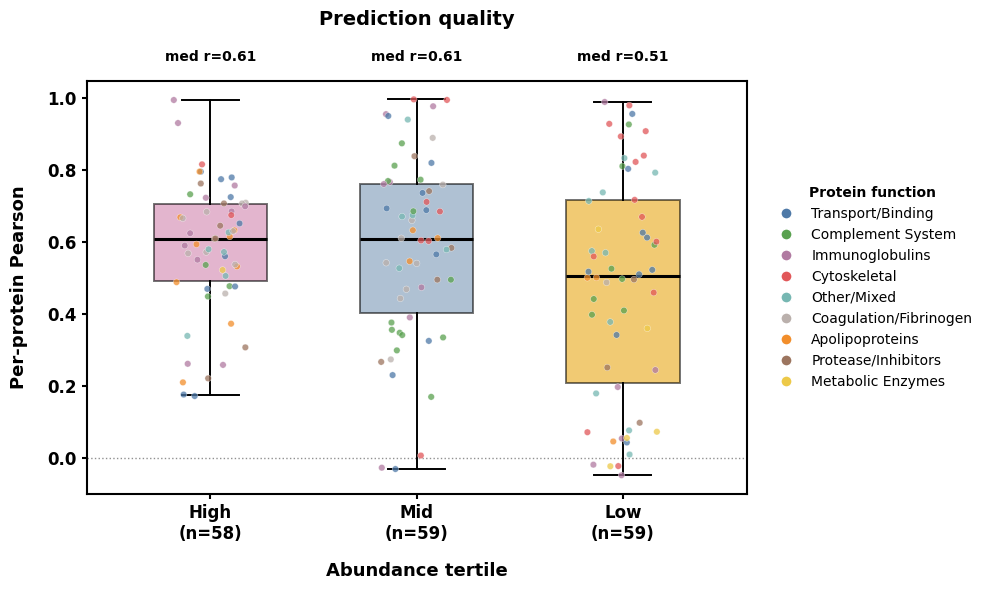

[OK] Figure saved → abundance_head_figures/tertile_boxes_plot.png


In [ ]:
# Create the folder for regression head figures
os.makedirs("abundance_head_figures", exist_ok=True)

def plot_tertile_boxes(
    per_prot_df,
    Ya_tr,
    save_path="abundance_head_figures/tertile_boxes_plot.png",
    seed=42,
):

    PIE_COLORS = [
        "#4E79A7", "#59A14F", "#B07AA1", "#E15759", "#76B7B2",
        "#BAB0AC", "#F28E2B", "#9C755F", "#EDC948",
    ]
    _pie_df  = audit_df[audit_df["n_proteins"] > 0].sort_values(
        "n_proteins", ascending=False
    )
    cat_color = {
        cat: PIE_COLORS[i % len(PIE_COLORS)]
        for i, cat in enumerate(_pie_df.index.tolist())
    }
    DEFAULT_CAT_COLOR = "#BAB0AC"  # fallback for Other/Mixed or unmapped

    def _color_for_protein(prot):
        cat = id_to_cat.get(prot, "Other/Mixed")
        return cat_color.get(cat, DEFAULT_CAT_COLOR)

    # ---- 1) Cconstruct tertile groups  ---
    K_total   = Ya_tr.shape[1]
    panel_idx = np.arange(K_total - 1)

    panel_mean_abund = Ya_tr[:, panel_idx].mean(axis=0)
    order            = np.argsort(-panel_mean_abund)
    n_panel          = len(order)

    high_idx = order[: n_panel // 3]
    mid_idx  = order[n_panel // 3 : 2 * n_panel // 3]
    low_idx  = order[2 * n_panel // 3 :]

    # ---- 2) Collect Pearson r per group and setting up colors----
    r_all = per_prot_df["pearson_r"].values

    def _collect(idx):
        rs   = r_all[idx]
        keep = ~np.isnan(rs)
        return rs[keep], idx[keep]

    r_high, i_high = _collect(high_idx)
    r_mid,  i_mid  = _collect(mid_idx)
    r_low,  i_low  = _collect(low_idx)

    groups = [
        ("High\n(n=58)", r_high, i_high, "#CC79A7"),  # pink
        ("Mid\n(n=59)",  r_mid,  i_mid,  "#6E8FB0"),  # blue
        ("Low\n(n=59)",  r_low,  i_low,  "#E69F00"),  # orange
    ]

    # ---- 3) Figure ----
    fig, ax = plt.subplots(figsize=(10, 6))

    positions = [1, 2, 3]
    rng       = np.random.default_rng(seed)

    # --- 3a) Box plot ---
    box_data = [g[1] for g in groups]
    bp = ax.boxplot(
        box_data,
        positions=positions,
        widths=0.55,
        patch_artist=True,
        showfliers=False,         # outliers shown via strip overlay instead
        medianprops=dict(color="black", linewidth=2.2),
        whiskerprops=dict(color="black", linewidth=1.4),
        capprops=dict(color="black", linewidth=1.4),
        boxprops=dict(linewidth=1.4, edgecolor="black"),
    )
    for patch, (_, _, _, col) in zip(bp["boxes"], groups):
        patch.set_facecolor(col)
        patch.set_alpha(0.55)

    # --- 3b) Strip overlay — each point colored by protein function category ---
    for pos, (_, rs, idxs, _) in zip(positions, groups):
        jitter      = rng.uniform(-0.18, 0.18, size=len(rs))
        pt_colors   = [_color_for_protein(OUT_COLS[j]) for j in idxs]
        ax.scatter(np.full(len(rs), pos) + jitter, rs,
                   s=22, alpha=0.75, c=pt_colors,
                   edgecolor="white", linewidth=0.3,
                   zorder=3)

    # ---- 4) Annotate each group with median r only -------------
    for pos, (label, rs, _, _) in zip(positions, groups):
        if len(rs) == 0:
            continue
        med = np.median(rs)
        ax.text(pos, 1.04, f"med r={med:.2f}",
                ha="center", va="bottom",
                fontsize=10, fontweight="bold",
                transform=ax.get_xaxis_transform())

    # ---- 5) r = 0 reference line --------------------------------
    ax.axhline(0.0, color="#909090", linestyle=":", linewidth=1.0, zorder=1)

    # ---- 6) Axis setup (AD-figure) ------------------------
    ax.set_xticks(positions)
    ax.set_xticklabels([g[0] for g in groups])

    ax.set_xlabel("Abundance tertile",
                  fontsize=13, fontweight="bold", labelpad=14)
    ax.set_ylabel("Per-protein Pearson",
                  fontsize=13, fontweight="bold", labelpad=14)
    ax.set_title("Prediction quality",
                 fontsize=14, fontweight="bold", pad=40)

    # Ticks — bold
    ax.tick_params(axis="both", which="major", labelsize=12, width=1.5)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight("bold")

    # Spines — bold black
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_edgecolor("black")

    # Give the box plot some breathing room on x
    ax.set_xlim(0.4, 3.6)

    # ---- 7) Category legend  ----
    present_cats = []
    for _, _, idxs, _ in groups:
        for j in idxs:
            c = id_to_cat.get(OUT_COLS[j], "Other/Mixed")
            if c not in present_cats:
                present_cats.append(c)
    present_cats = [c for c in _pie_df.index.tolist() if c in present_cats] + \
                   [c for c in present_cats if c not in _pie_df.index.tolist()]

    handles = [
        Line2D([0], [0], marker="o", linestyle="",
               markerfacecolor=cat_color.get(c, DEFAULT_CAT_COLOR),
               markeredgecolor="white", markersize=8, label=c)
        for c in present_cats
    ]
    leg = ax.legend(handles=handles, title="Protein function",
                    loc="center left", bbox_to_anchor=(1.02, 0.5),
                    fontsize=10, frameon=False)
    leg.get_title().set_fontweight("bold")

    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"[OK] Figure saved → {save_path}")


plot_tertile_boxes(per_prot_df, Ya_tr)

## 9.2 Predicted vs. observed scatter

[INFO] N points (panel only)  : 13,920
[INFO] Observed nonzero min   : 1.04e-05
[INFO] Predicted nonzero min  : 1.15e-13
[INFO] Observed max           : 0.6010
[INFO] Zero fraction (obs)    : 65.6%
[INFO] ε floor used           : 1e-04


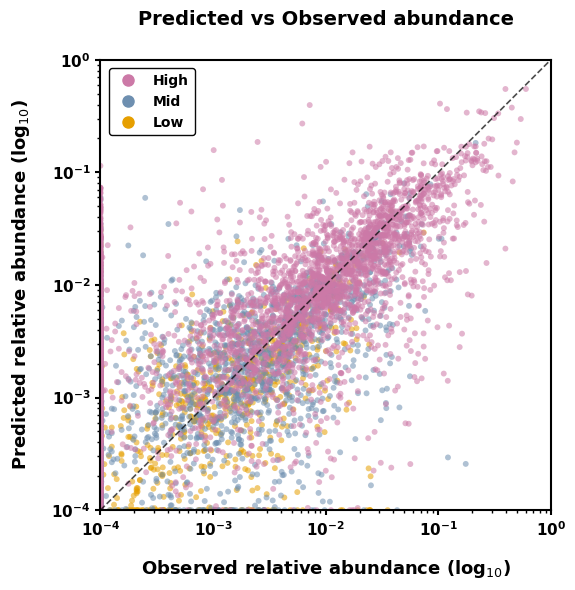

[OK] Figure saved → abundance_head_figures/pred_vs_obs_plot.png


In [ ]:
TERTILE_ORDER  = ["High", "Mid", "Low"]
TERTILE_COLORS = {
    "High": "#CC79A7",
    "Mid" : "#6E8FB0",
    "Low" : "#E69F00",
}

def plot_pred_vs_obs_by_tertile(
    Ya_te,
    D_test,
    Ya_tr,
    OUT_COLS,
    save_path="abundance_head_figures/pred_vs_obs_plot.png",
    eps=1e-4,
    point_size=18,
    alpha=0.55,
):
    # ---- 1) Drop OTHER and build tertile membership ------------
    K_total   = Ya_tr.shape[1]
    panel_idx = np.arange(K_total - 1)

    panel_mean_abund = Ya_tr[:, panel_idx].mean(axis=0)
    order            = np.argsort(-panel_mean_abund)
    n_panel          = len(order)

    high_idx = order[: n_panel // 3]
    mid_idx  = order[n_panel // 3 : 2 * n_panel // 3]
    low_idx  = order[2 * n_panel // 3 :]

    tertile_members = {"High": high_idx, "Mid": mid_idx, "Low": low_idx}

    # ---- 2) Collect (obs, pred) per tertile --------------------
    obs_by_t  = {}
    pred_by_t = {}
    for t, idx in tertile_members.items():
        obs_by_t[t]  = Ya_te[:, idx].flatten()
        pred_by_t[t] = D_test[:, idx].flatten()

    all_obs  = np.concatenate([obs_by_t[t] for t in TERTILE_ORDER])
    all_pred = np.concatenate([pred_by_t[t] for t in TERTILE_ORDER])

    # ---- 3) Sanity print ---------------------------------------
    print(f"[INFO] N points (panel only)  : {len(all_obs):,}")
    print(f"[INFO] Observed nonzero min   : {all_obs[all_obs > 0].min():.2e}")
    print(f"[INFO] Predicted nonzero min  : {all_pred[all_pred > 0].min():.2e}")
    print(f"[INFO] Observed max           : {all_obs.max():.4f}")
    print(f"[INFO] Zero fraction (obs)    : {(all_obs == 0).mean():.1%}")
    print(f"[INFO] ε floor used           : {eps:.0e}")

    def _floor(a):
        return np.maximum(a, eps)

    # ---- 4) Figure ---------------------------------------------
    fig, ax = plt.subplots(figsize=(6, 6))

    plot_order = ["Low", "Mid", "High"]
    for t in plot_order:
        ax.scatter(_floor(obs_by_t[t]), _floor(pred_by_t[t]),
                   s=point_size,
                   alpha=alpha,
                   color=TERTILE_COLORS[t],
                   edgecolor="none",
                   label=f"{t}",
                   zorder=2)

    # ---- 5) Diagonal -------------------------------------------
    lim_lo = eps
    lim_hi = 1.0
    ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi],
            color="black", linestyle="--", linewidth=1.2,
            alpha=0.7, zorder=3,
            label="y = x")

    # ---- 6) Axes -----------------------------------------------
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(lim_lo, lim_hi)
    ax.set_ylim(lim_lo, lim_hi)
    ax.set_aspect("equal", adjustable="box")

    ax.set_xlabel("Observed relative abundance (log$_{10}$)",
                  fontsize=13, fontweight="bold", labelpad=14)
    ax.set_ylabel("Predicted relative abundance (log$_{10}$)",
                  fontsize=13, fontweight="bold", labelpad=14)
    ax.set_title("Predicted vs Observed abundance",
                 fontsize=14, fontweight="bold", pad=25)

    ax.tick_params(axis="both", which="major", labelsize=11, width=1.5)
    ax.tick_params(axis="both", which="minor", width=1.0)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight("bold")

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_edgecolor("black")

    # ---- 7) Legend ------
    legend_handles = [
        Line2D([0], [0],
               marker="o", linestyle="",
               color=TERTILE_COLORS[t],
               markersize=8,
               label=f"{t}")
        for t in TERTILE_ORDER
    ]

    legend = ax.legend(
        handles=legend_handles,
        loc="upper left",
        fontsize=10,
        framealpha=0.97,
        borderaxespad=0.6,
    )
    for text in legend.get_texts():
        text.set_fontweight("bold")
    legend.get_frame().set_edgecolor("black")
    legend.get_frame().set_linewidth(1.0)

    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"[OK] Figure saved → {save_path}")


plot_pred_vs_obs_by_tertile(
    Ya_te    = Ya_te,
    D_test   = D_test,
    Ya_tr    = Ya_tr,
    OUT_COLS = OUT_COLS,
)